# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Isi Nama Kalian | Isi NRP Kalian |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [76]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [77]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [78]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
!pip install -q kagglehub[pandas-datasets]

import kagglehub

# Download dataset dari Kaggle
path = kagglehub.dataset_download("abbas829/bankruptcy")

print("Dataset tersimpan di:")
print(path)


Using Colab cache for faster access to the 'bankruptcy' dataset.
Dataset tersimpan di:
/kaggle/input/bankruptcy


In [79]:
import os

print("Isi dataset:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Isi dataset:
/kaggle/input/bankruptcy/bankruptcy.csv


In [80]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abbas829/bankruptcy",
    "bankruptcy.csv"
)

print(df.head())

/tmp/ipykernel_1115/3058865264.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'bankruptcy' dataset.
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                         

In [81]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

Hilangkan strip dan spasi parah

In [82]:
# Bersihkan spasi di awal dan akhir nama kolom
df.columns = df.columns.str.strip()

print(df.columns.tolist())


['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue', 'Continuous interest rate (after tax)', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Operating Profit Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'After-tax Net Profit Growth Rate', 'Regular Net Profit Growth Rate', 'Continuous Net Profit Growth Rate', 'Total Asset Growth R

In [83]:
print(f"Dimensi dataset: {df.shape}")

Dimensi dataset: (6819, 96)


In [84]:
print(f"\nTipe data kolom:\n{df.dtypes}")


Tipe data kolom:
Bankrupt?                                                    int64
ROA(C) before interest and depreciation before interest    float64
ROA(A) before interest and % after tax                     float64
ROA(B) before interest and depreciation after tax          float64
Operating Gross Margin                                     float64
Realized Sales Gross Margin                                float64
Operating Profit Rate                                      float64
Pre-tax net Interest Rate                                  float64
After-tax net Interest Rate                                float64
Non-industry income and expenditure/revenue                float64
Continuous interest rate (after tax)                       float64
Operating Expense Rate                                     float64
Research and development expense rate                      float64
Cash flow rate                                             float64
Interest-bearing debt interest rate         

In [85]:
print(f"\nStatistik deskriptif:\n{df.describe().T}")


Statistik deskriptif:
                                                     count          mean  \
Bankrupt?                                           6819.0  3.226280e-02   
ROA(C) before interest and depreciation before ...  6819.0  5.051796e-01   
ROA(A) before interest and % after tax              6819.0  5.586249e-01   
ROA(B) before interest and depreciation after tax   6819.0  5.535887e-01   
Operating Gross Margin                              6819.0  6.079480e-01   
Realized Sales Gross Margin                         6819.0  6.079295e-01   
Operating Profit Rate                               6819.0  9.987551e-01   
Pre-tax net Interest Rate                           6819.0  7.971898e-01   
After-tax net Interest Rate                         6819.0  8.090836e-01   
Non-industry income and expenditure/revenue         6819.0  3.036229e-01   
Continuous interest rate (after tax)                6819.0  7.813814e-01   
Operating Expense Rate                              6819.0  1.995

In [86]:
print(f"\nJumlah missing value:\n{df.isna().sum()}")


Jumlah missing value:
Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
Realized Sales Gross Margin                                0
Operating Profit Rate                                      0
Pre-tax net Interest Rate                                  0
After-tax net Interest Rate                                0
Non-industry income and expenditure/revenue                0
Continuous interest rate (after tax)                       0
Operating Expense Rate                                     0
Research and development expense rate                      0
Cash flow rate                                             0
Interest-bearing debt interest rate                        0
Tax rate (A)                                               0
N

In [87]:
display(df.nunique())

,0
Bankrupt?,2
ROA(C) before interest and depreciation before interest,3333
ROA(A) before interest and % after tax,3151
ROA(B) before interest and depreciation after tax,3160
Operating Gross Margin,3781
Realized Sales Gross Margin,3788
Operating Profit Rate,3376
Pre-tax net Interest Rate,3789
After-tax net Interest Rate,3604
Non-industry income and expenditure/revenue,2551


Buang fitur yang gak punya nilai unik sama sekali

In [88]:
df = df.drop(columns=['Net Income Flag'])

In [89]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
X= df.drop(columns=['Bankrupt?'])
Y= df['Bankrupt?']
X.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.006889,0.391590,0.012335,0.751111,0.

In [90]:

# Jumlah masing-masing kelas
print(df['Bankrupt?'].value_counts(), " : ", df['Bankrupt?'].value_counts(normalize=True) * 100)



Bankrupt?
0    6599
1     220
Name: count, dtype: int64  :  Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


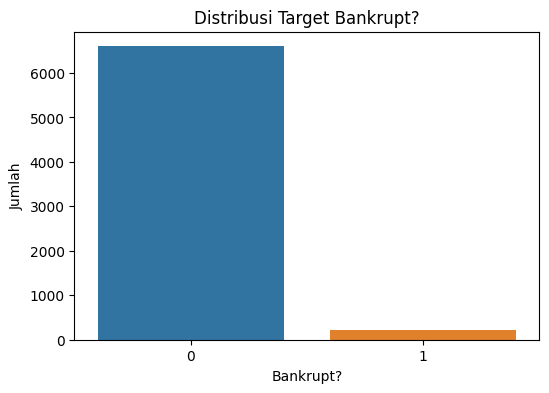

In [91]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Bankrupt?', hue='Bankrupt?', legend=False)

plt.title('Distribusi Target Bankrupt?')
plt.xlabel('Bankrupt?')
plt.ylabel('Jumlah')
plt.show()

**IMBALANCE PARAH**

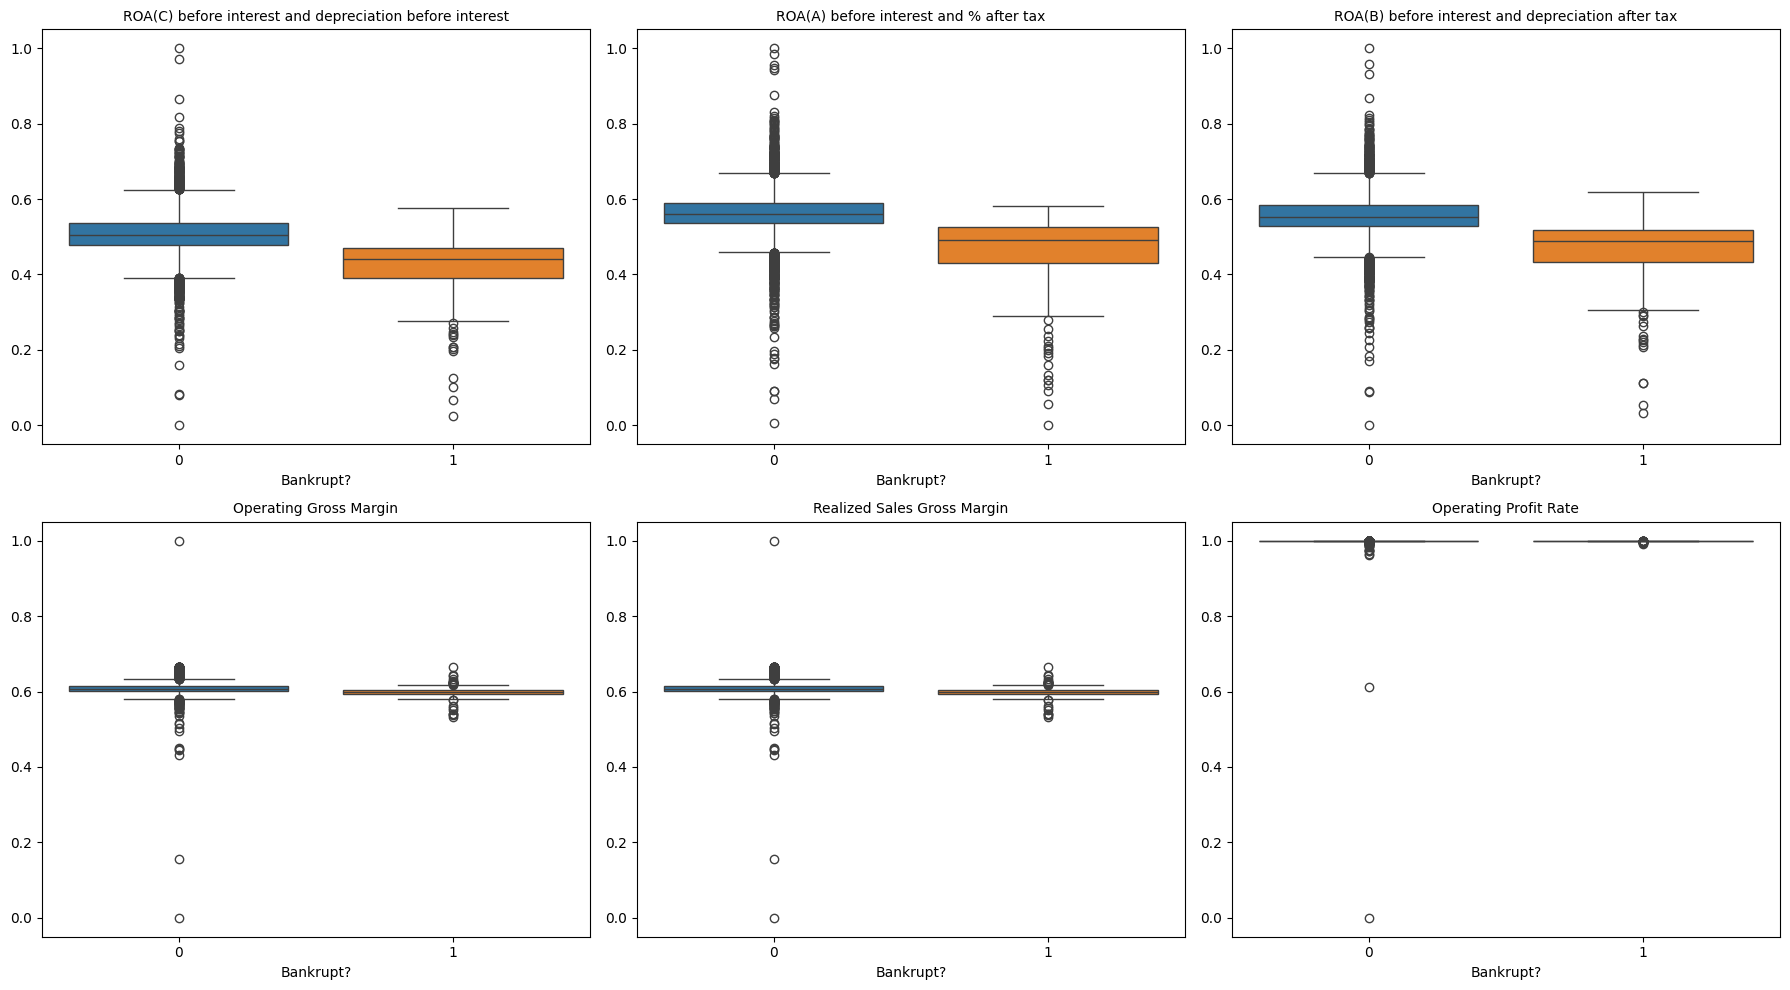

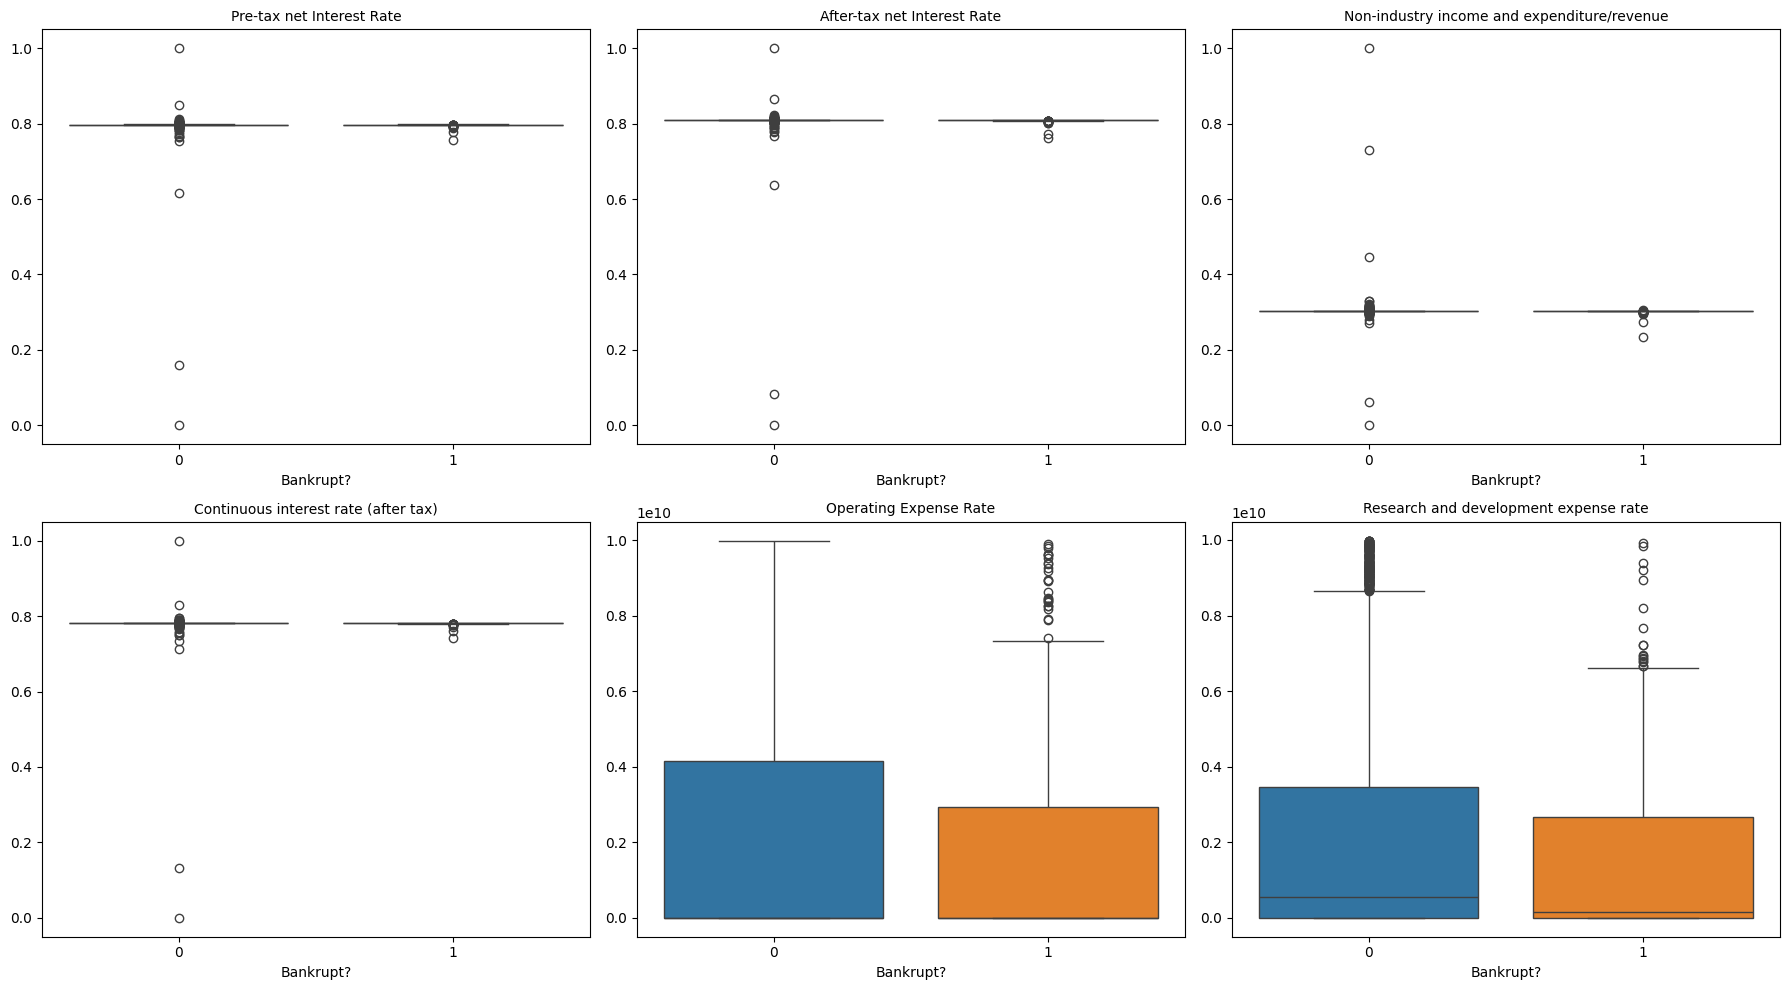

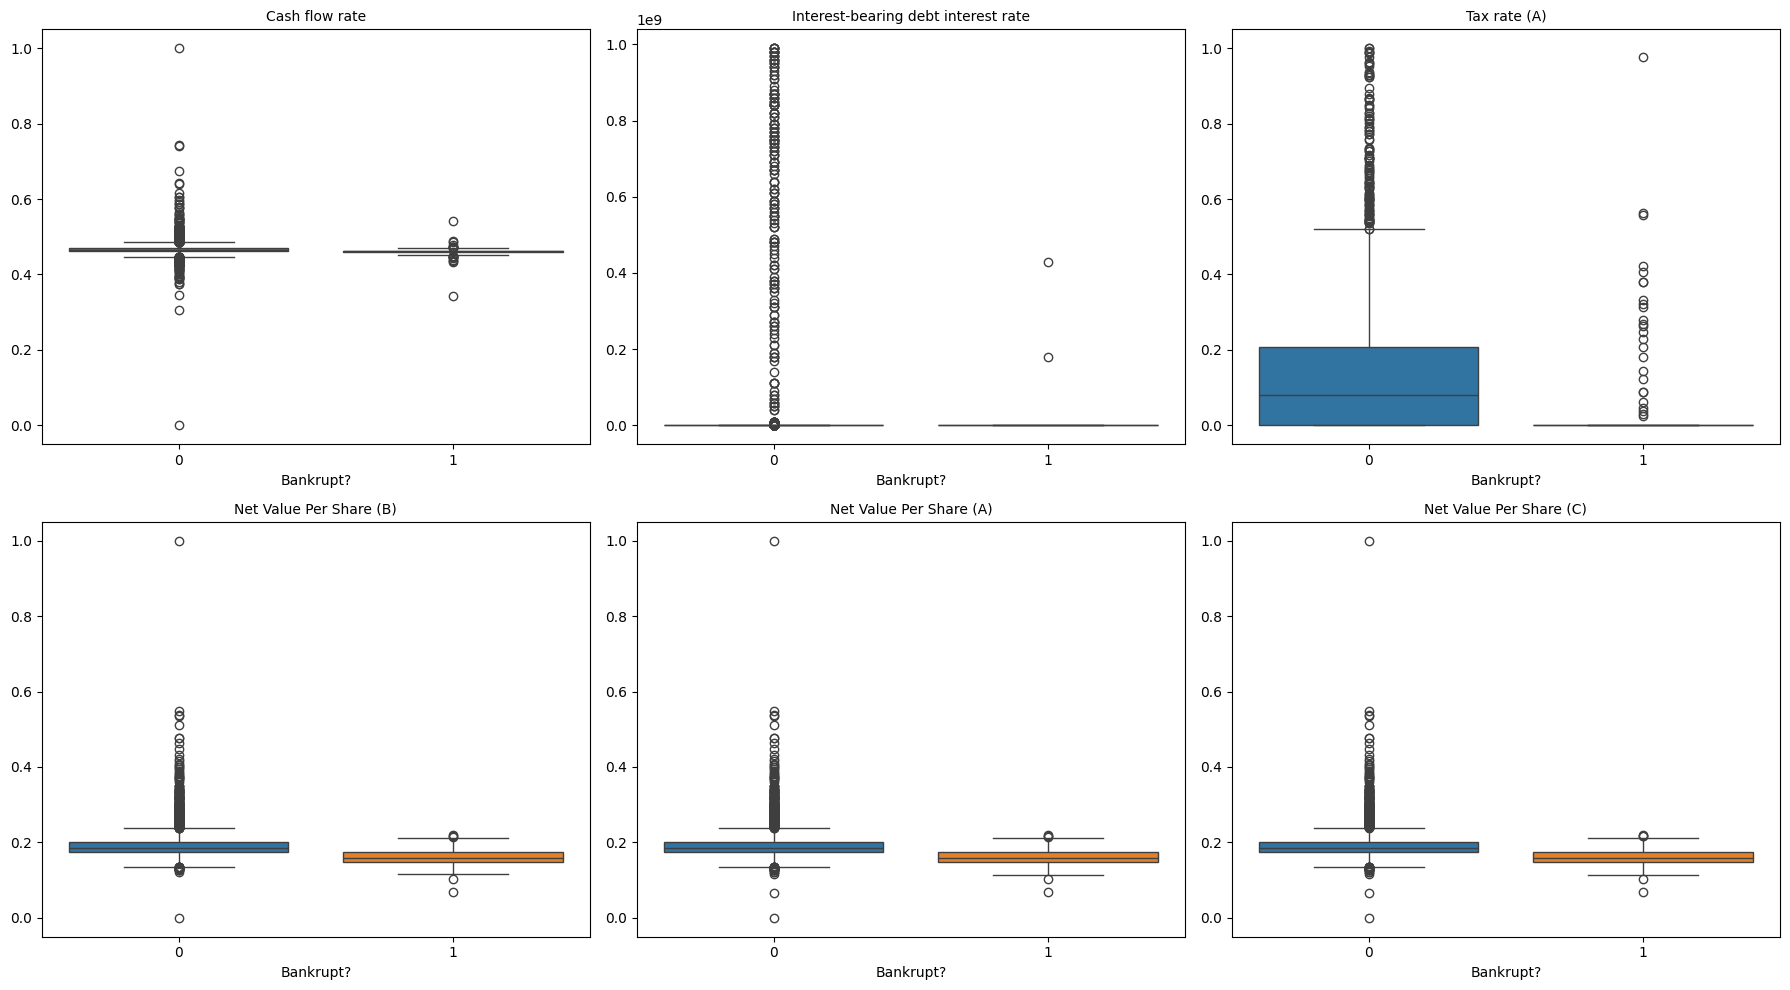

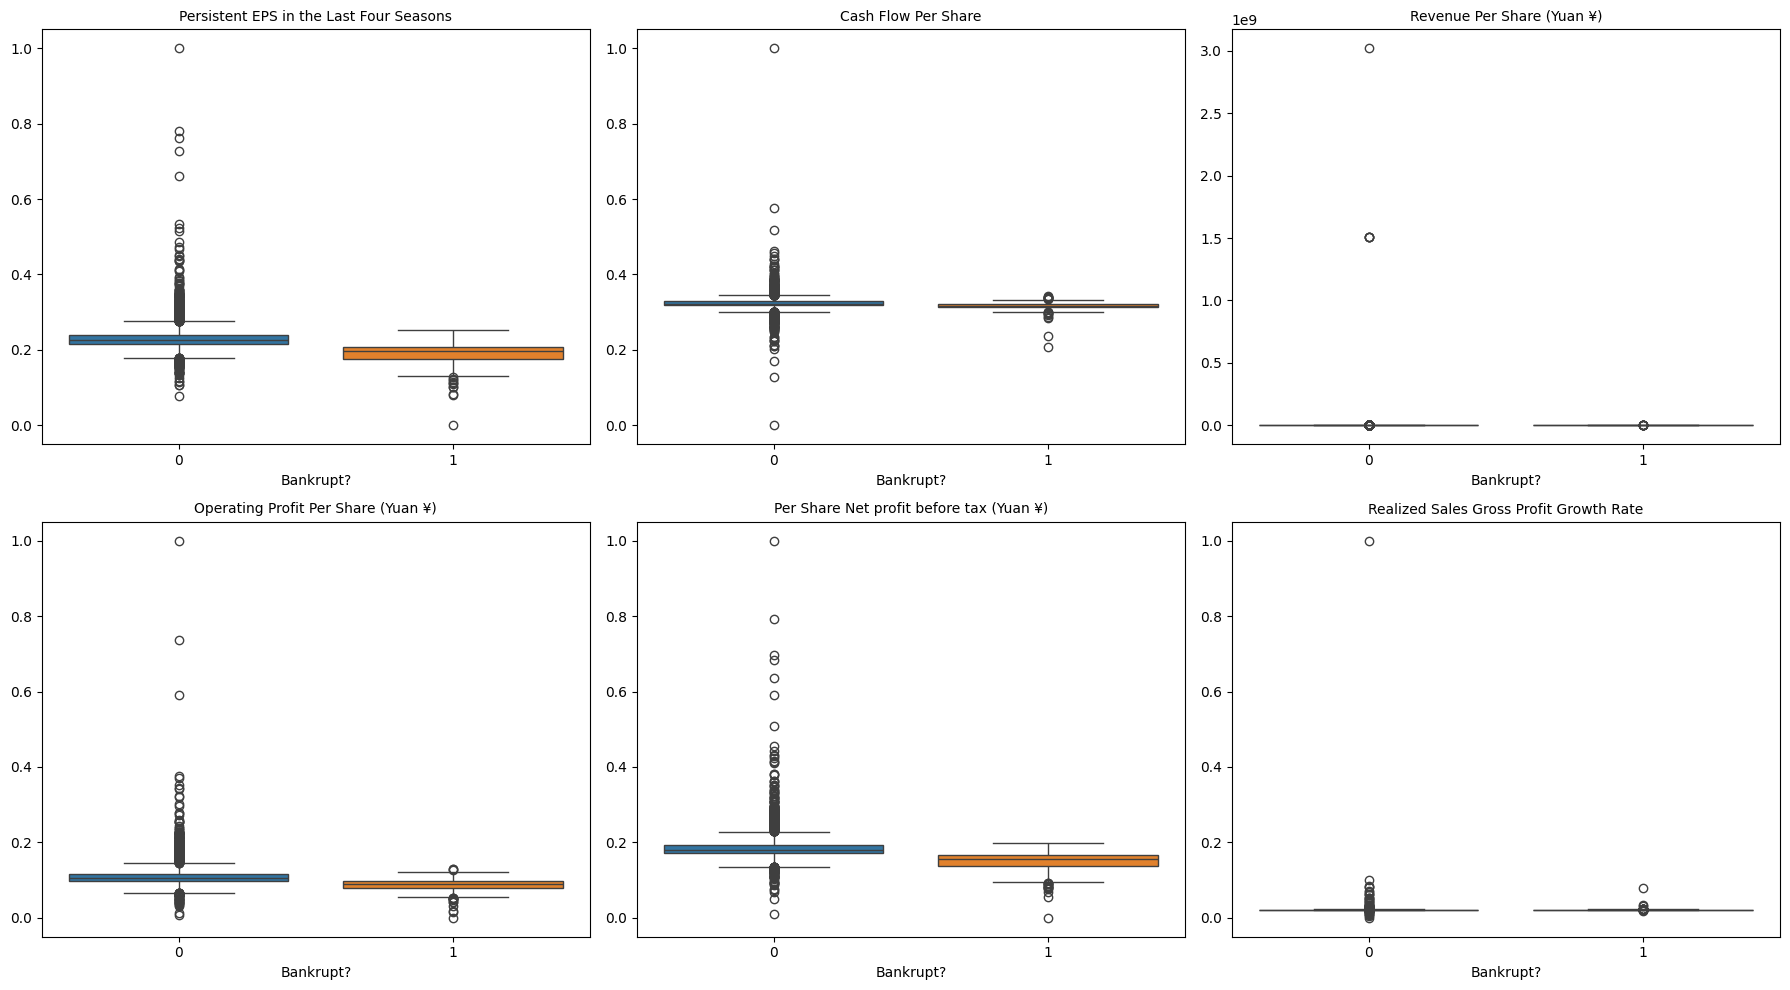

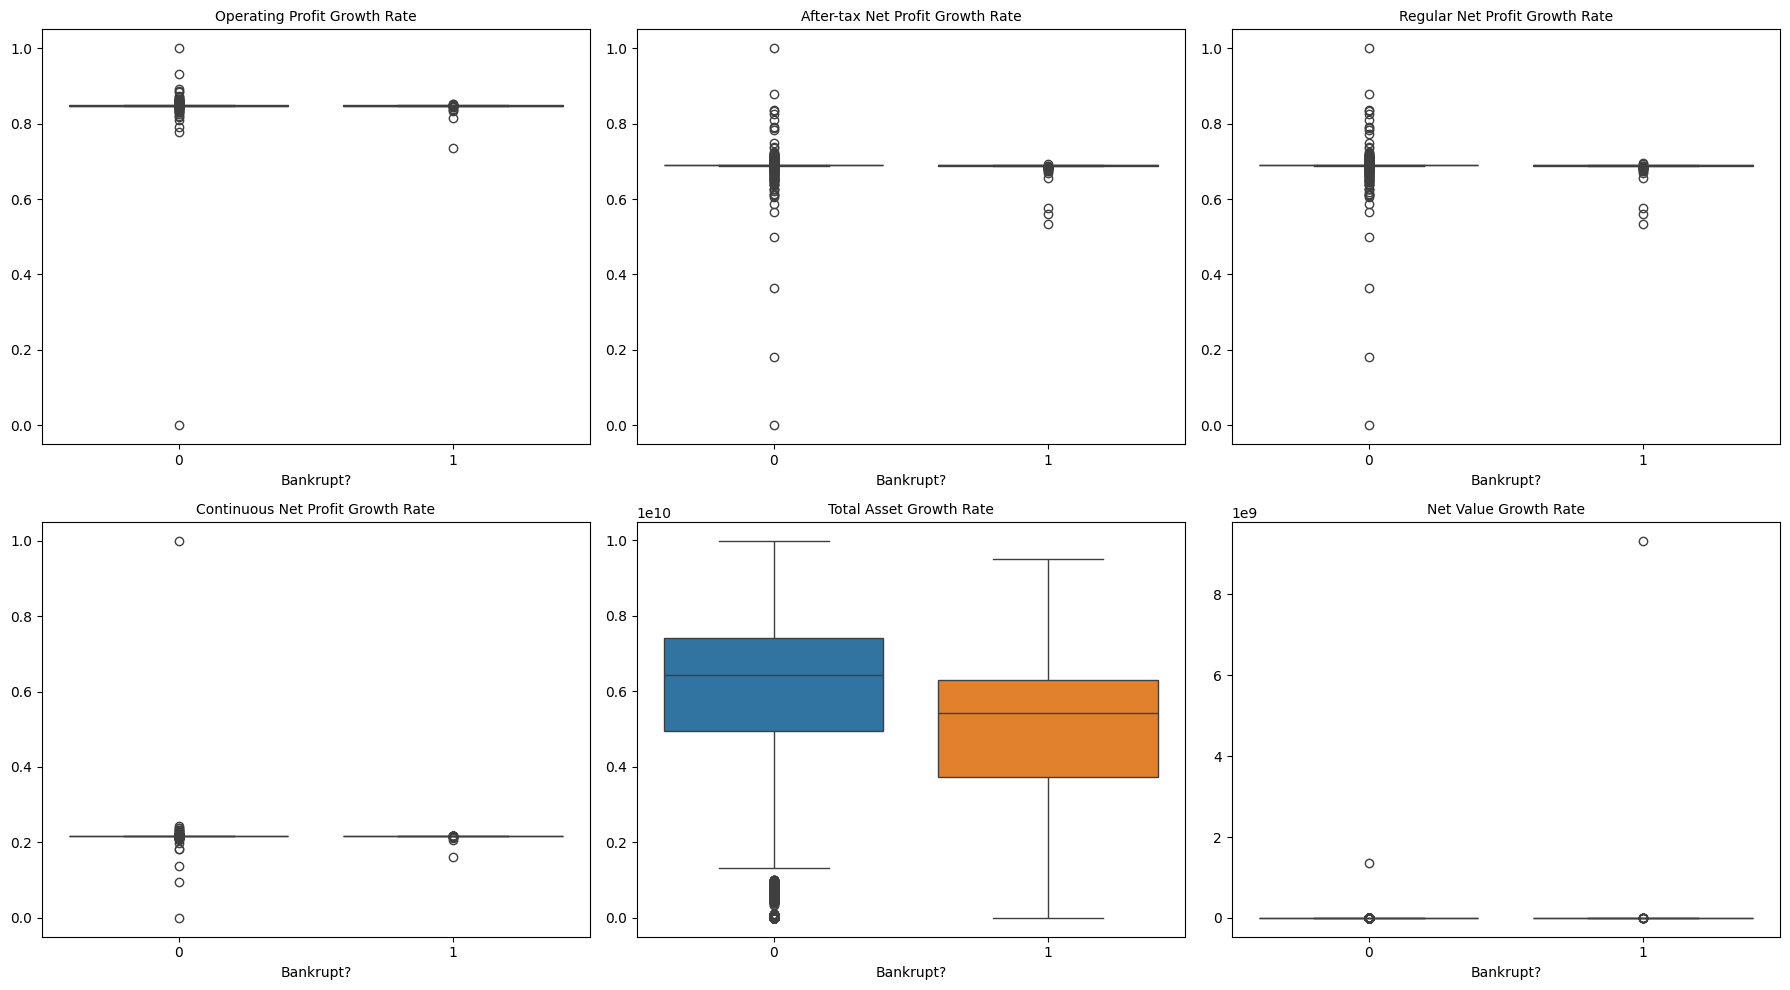

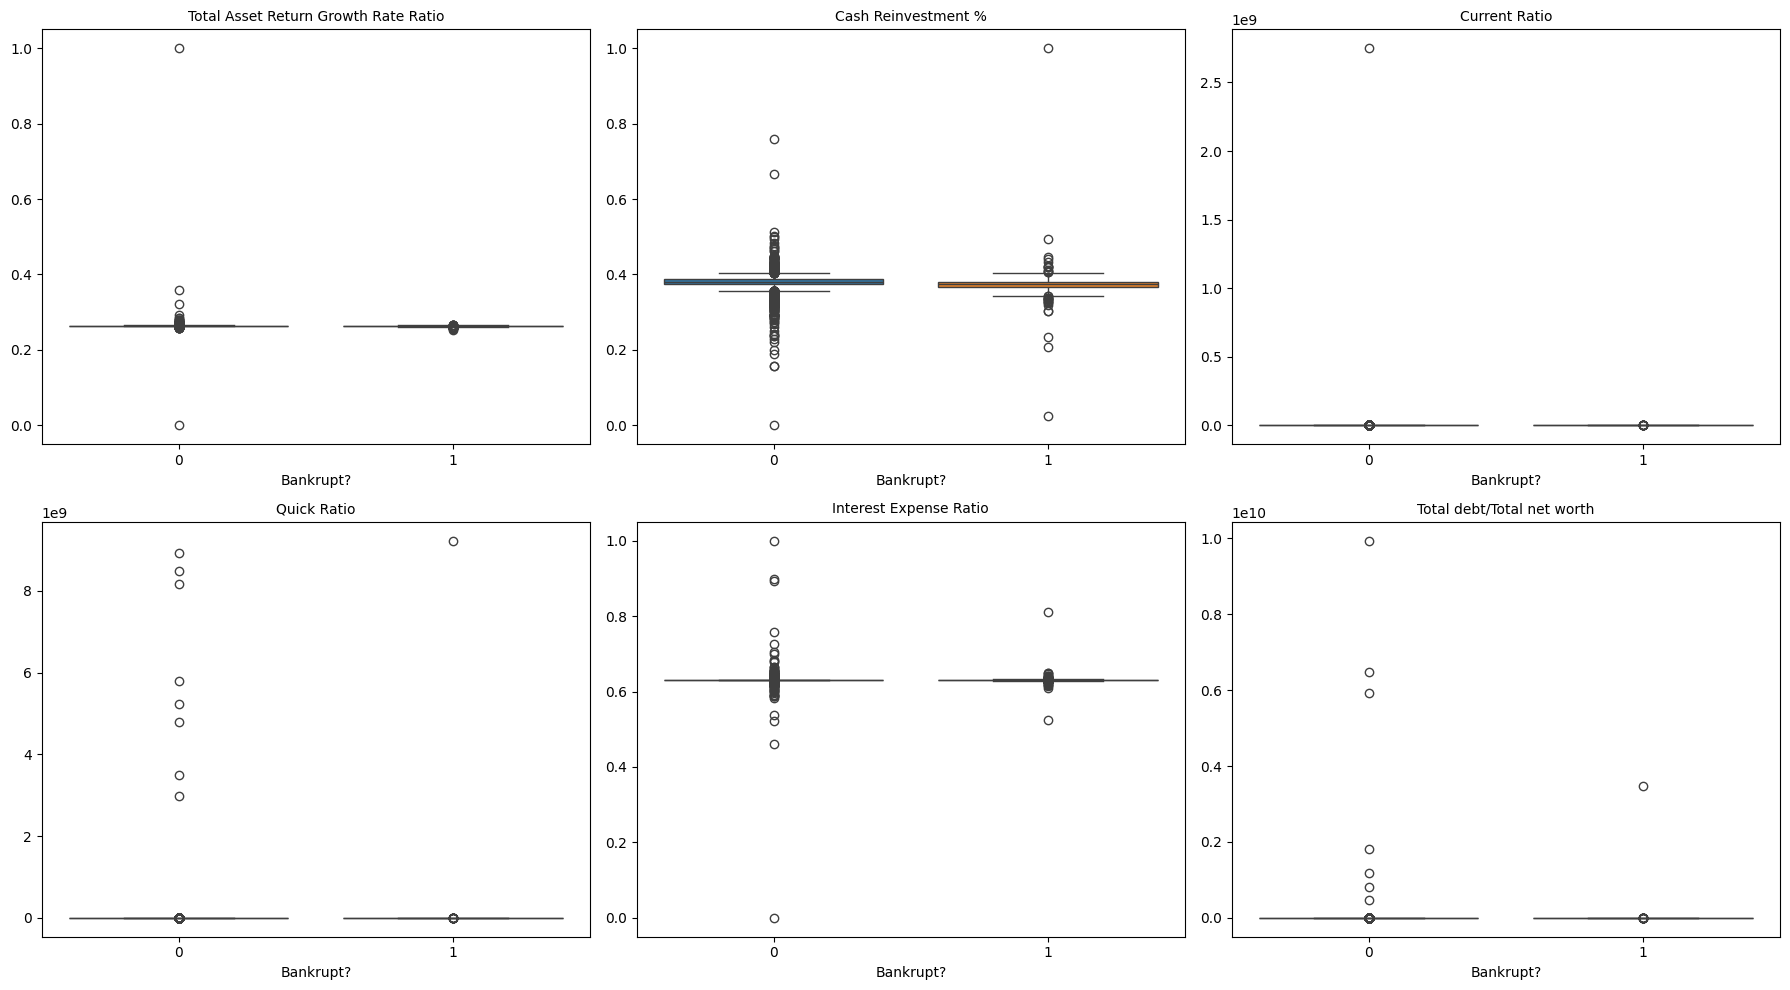

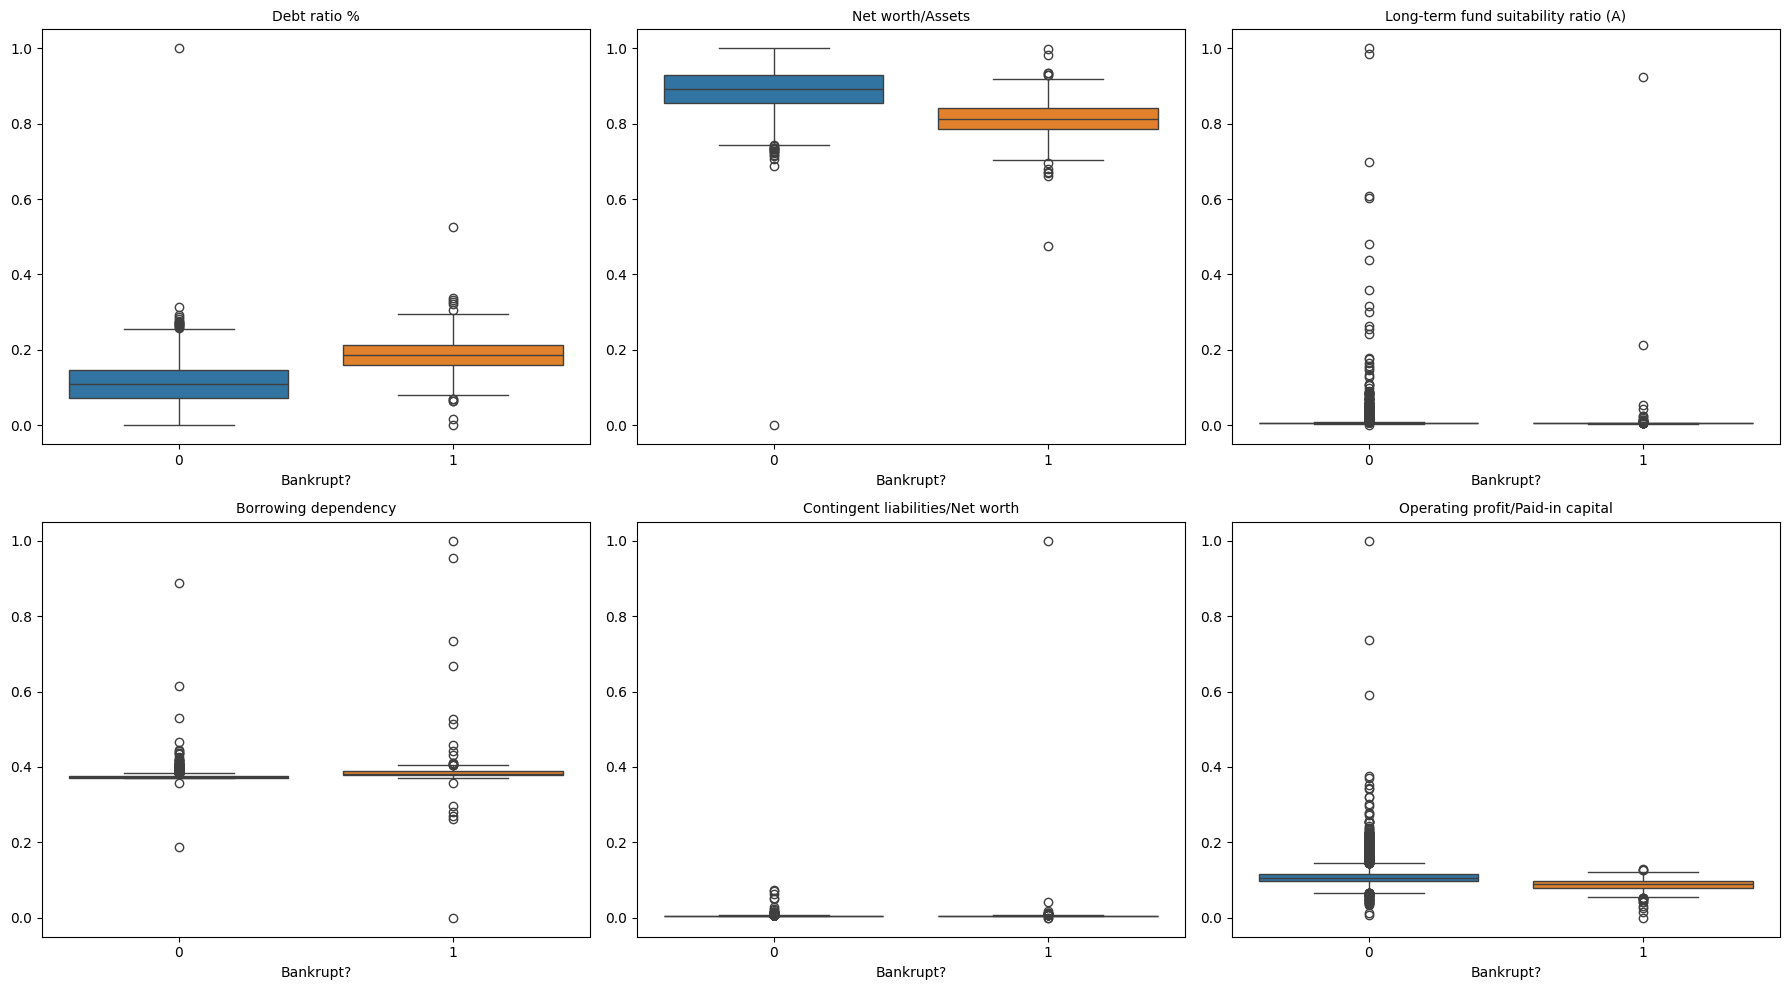

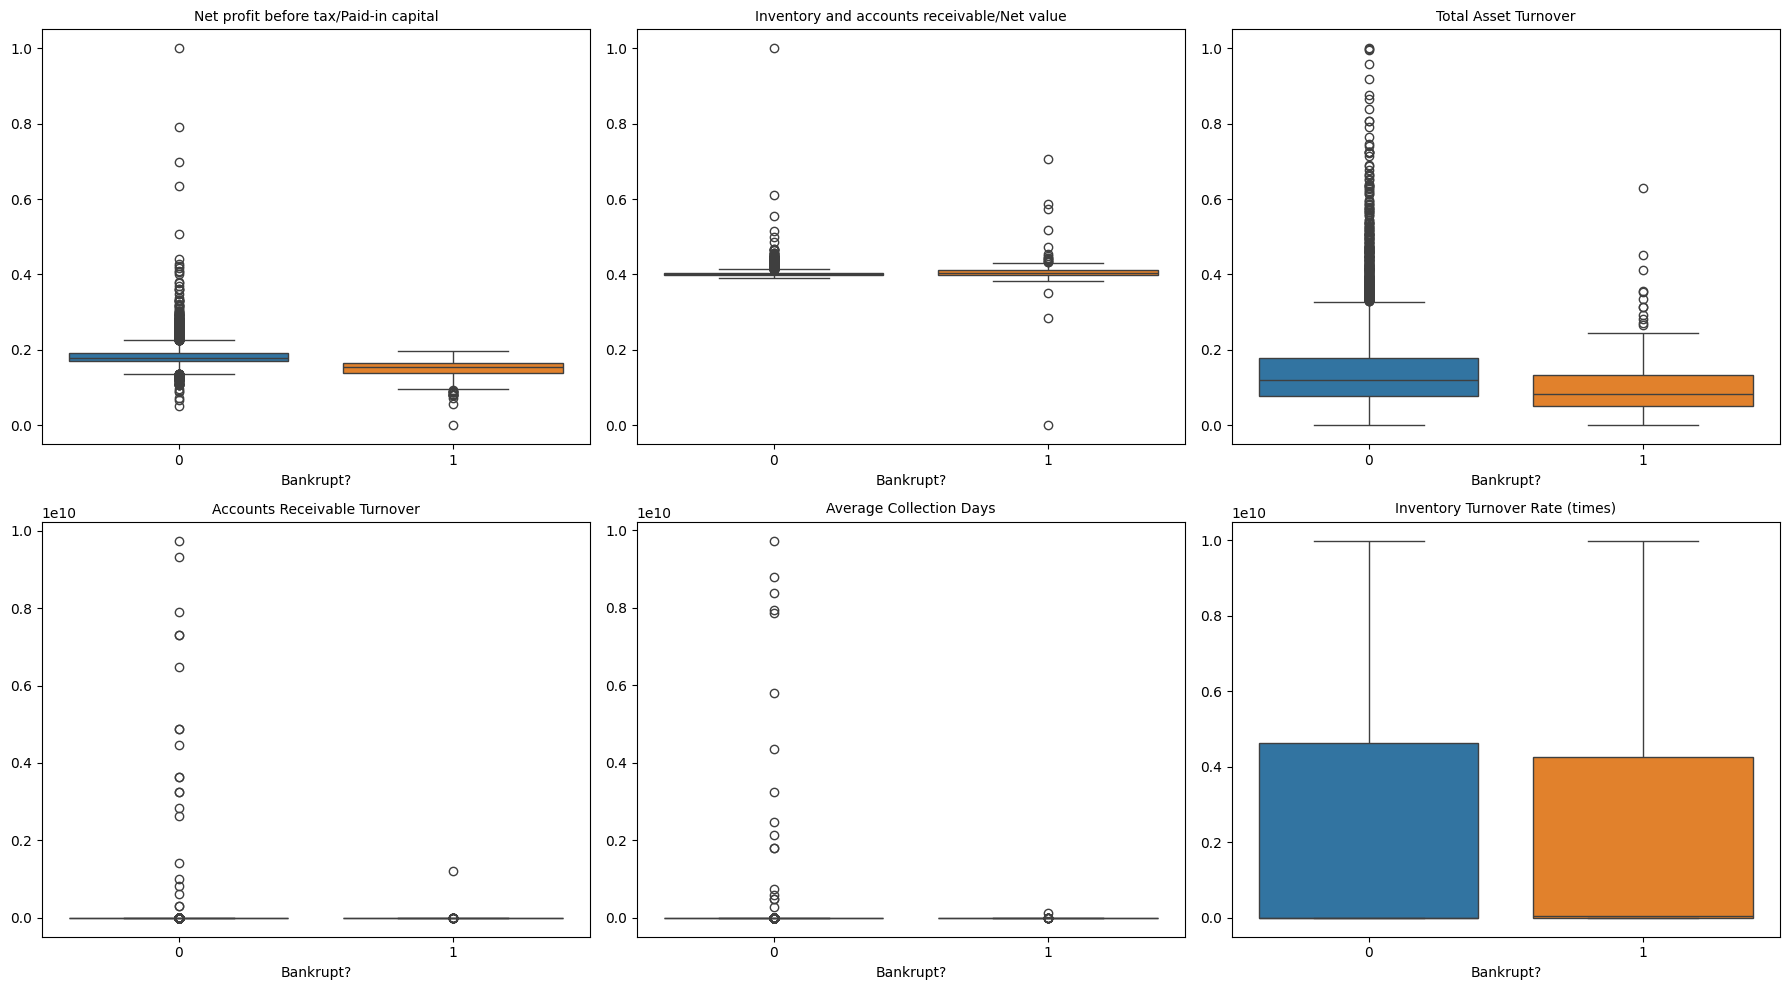

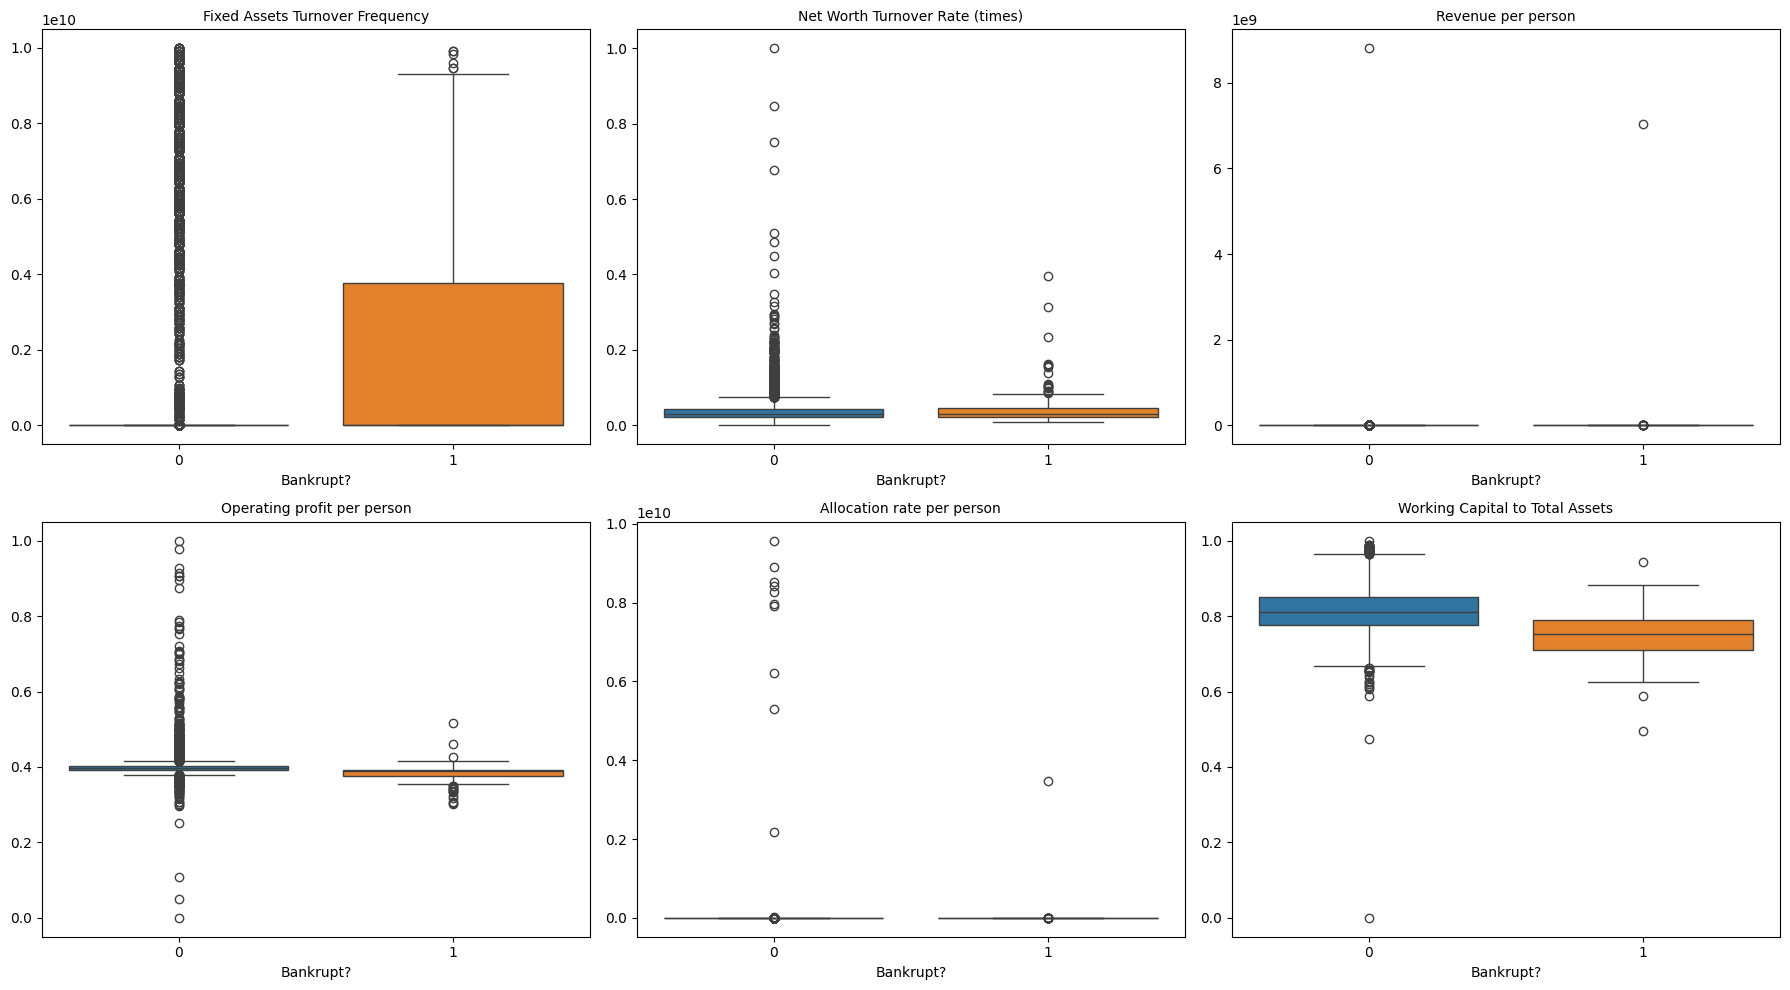

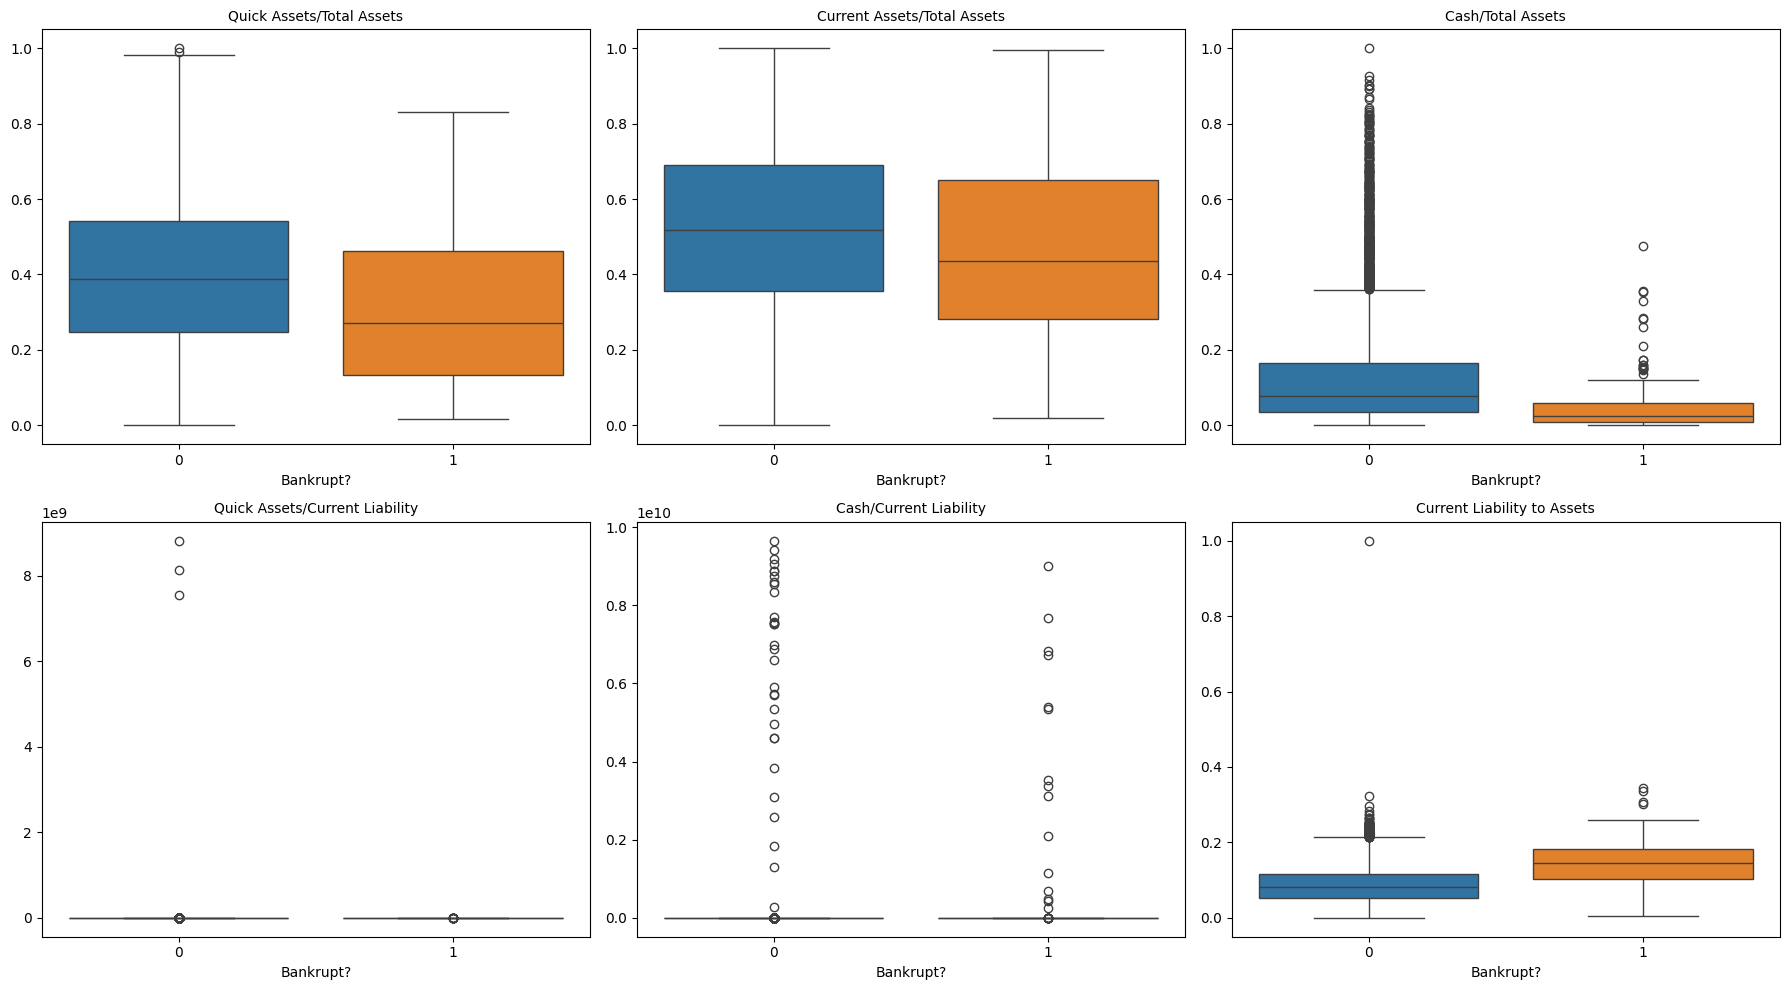

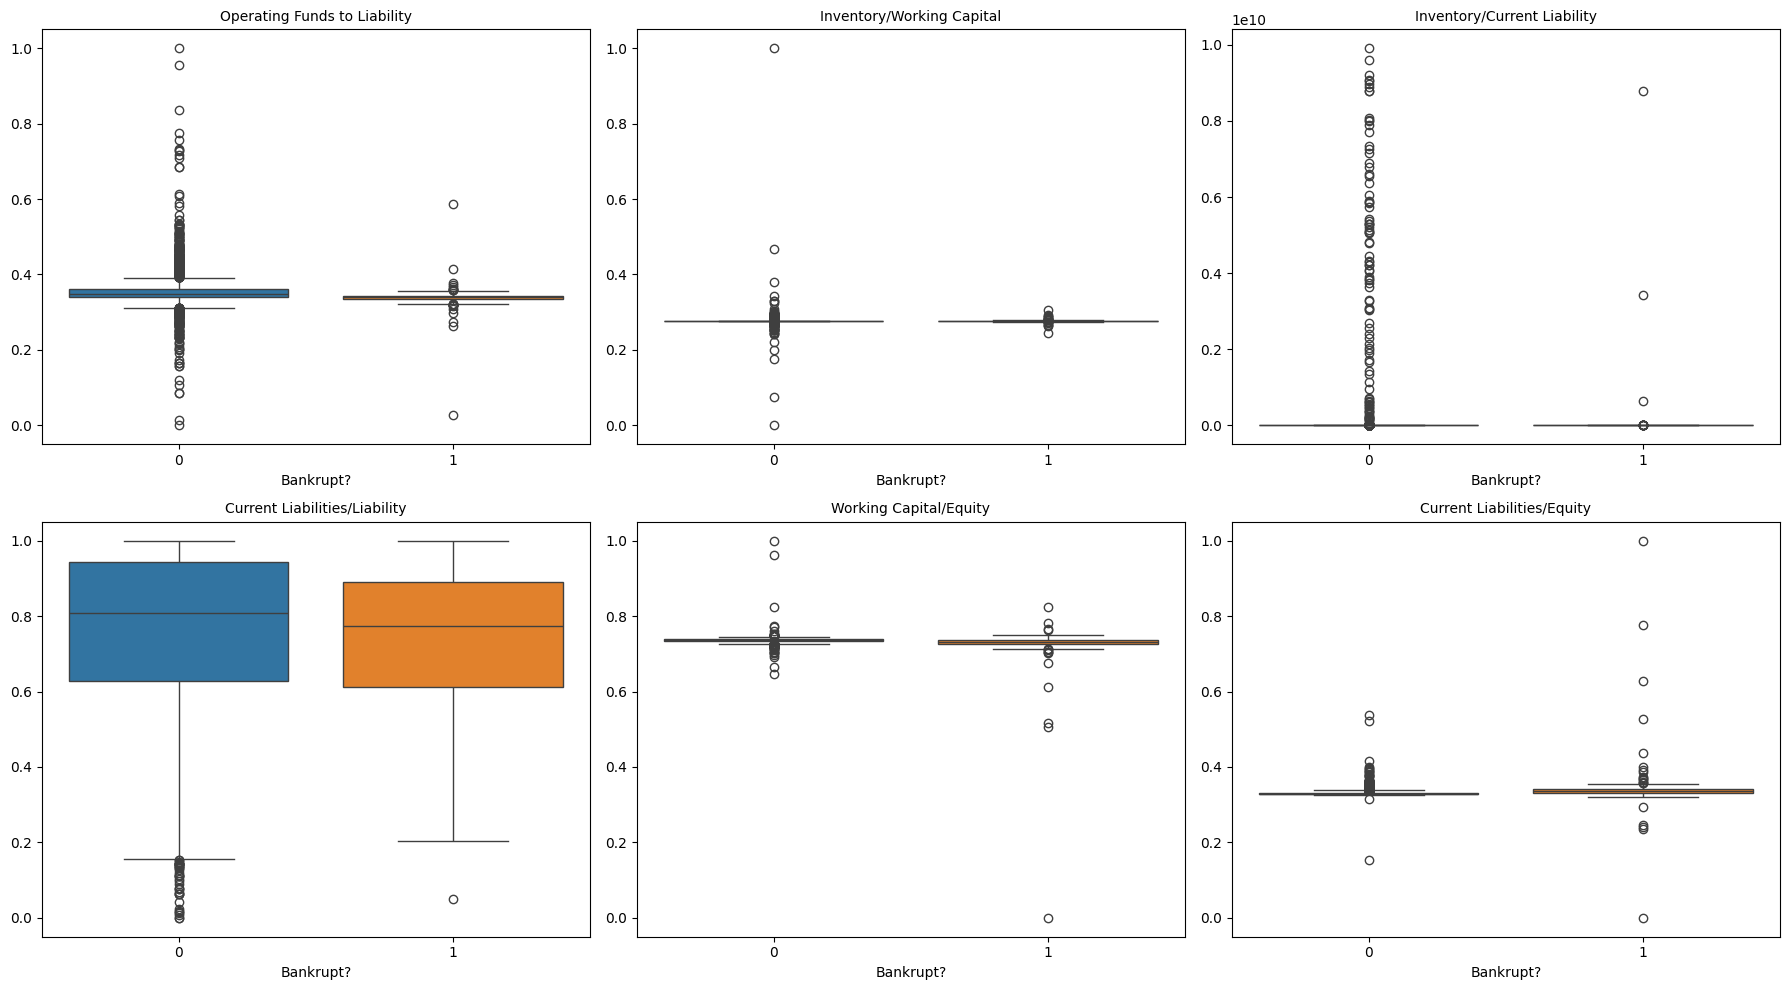

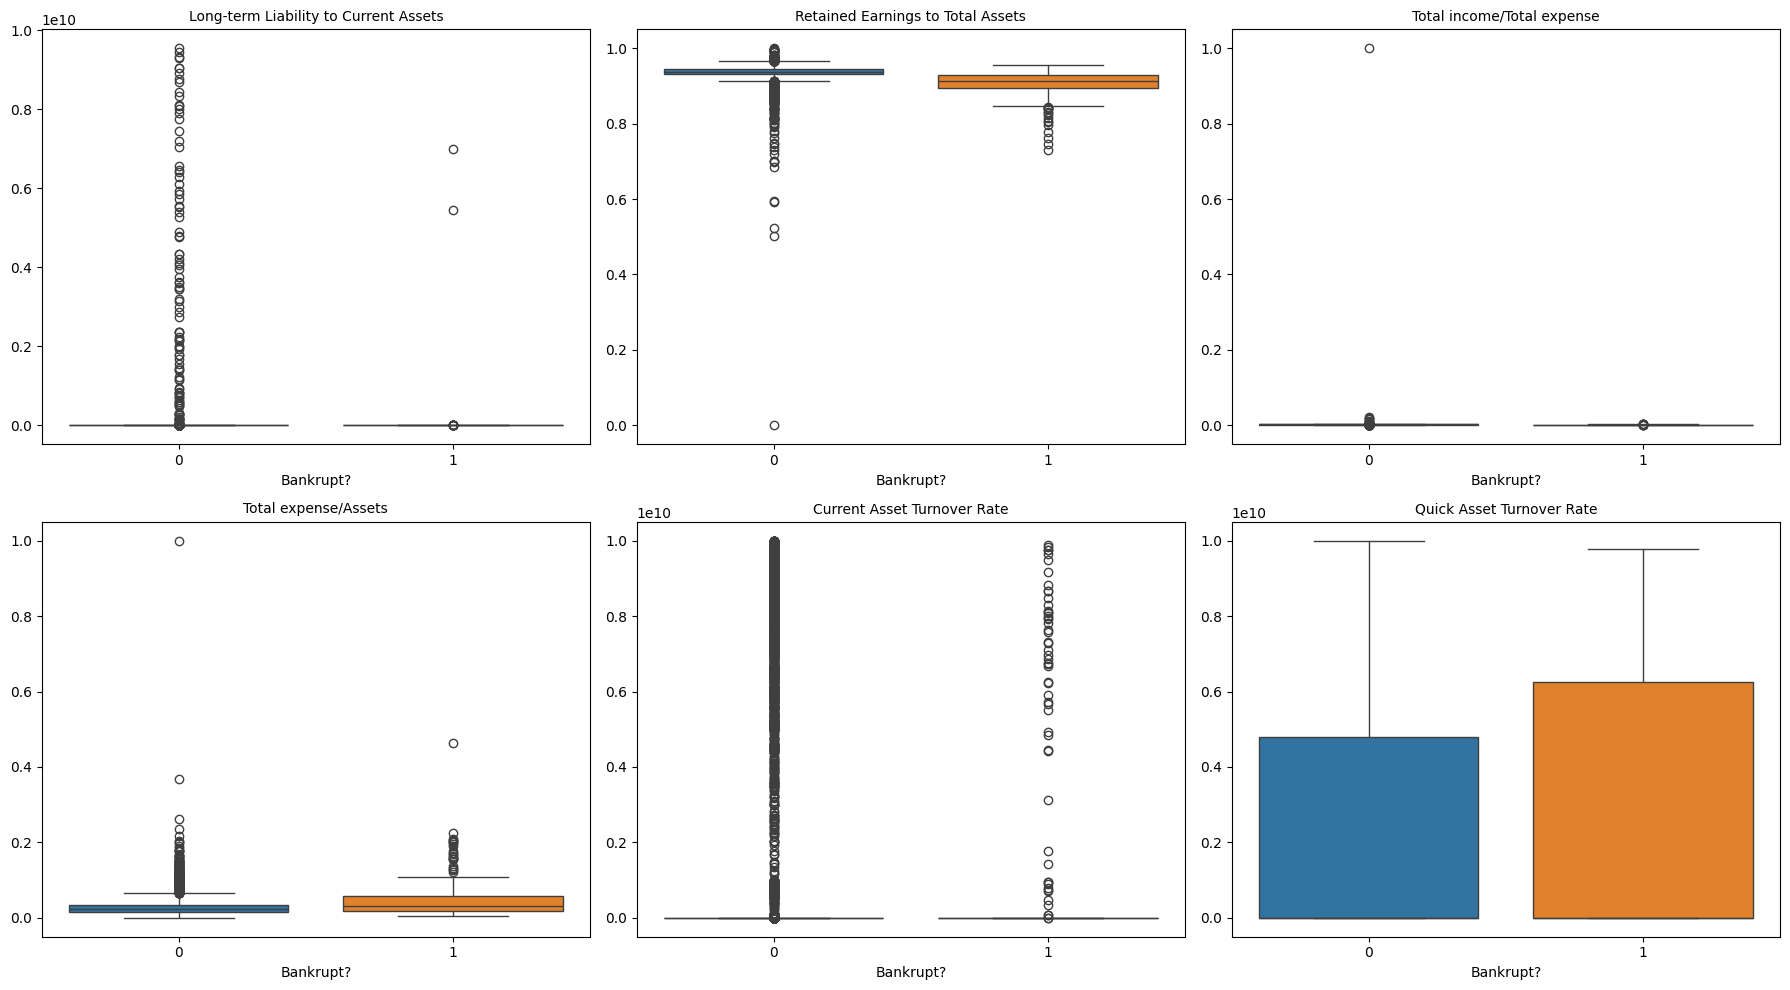

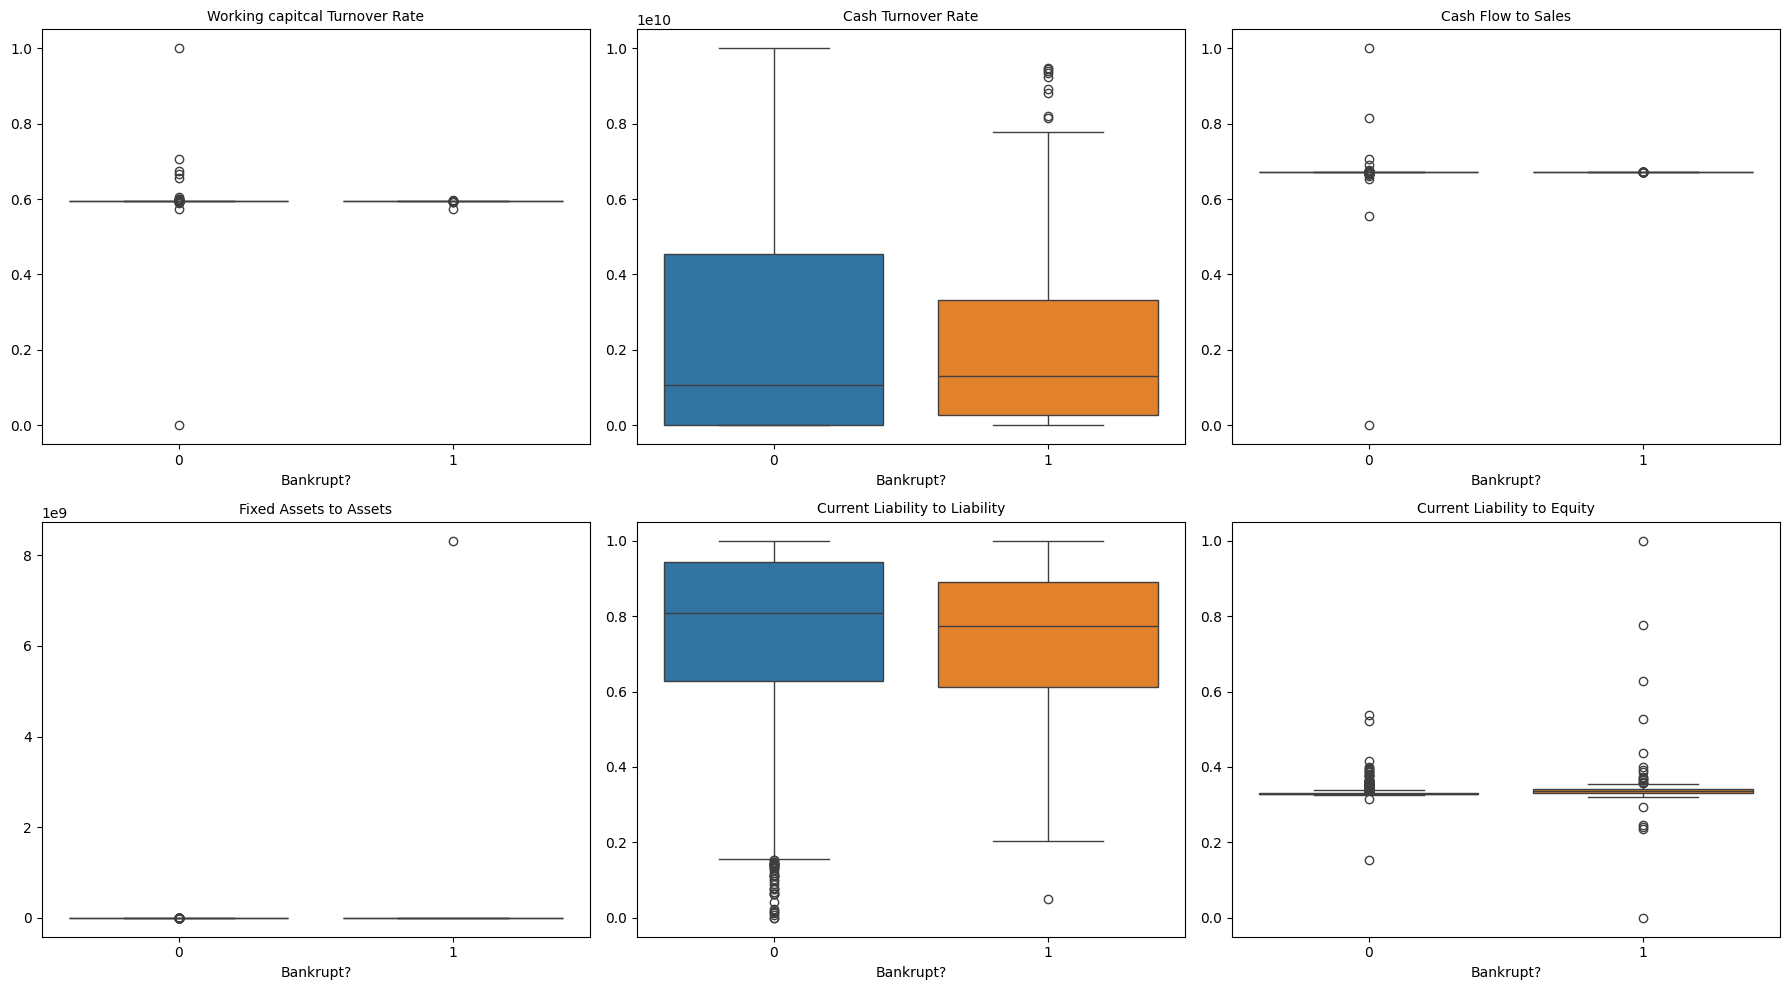

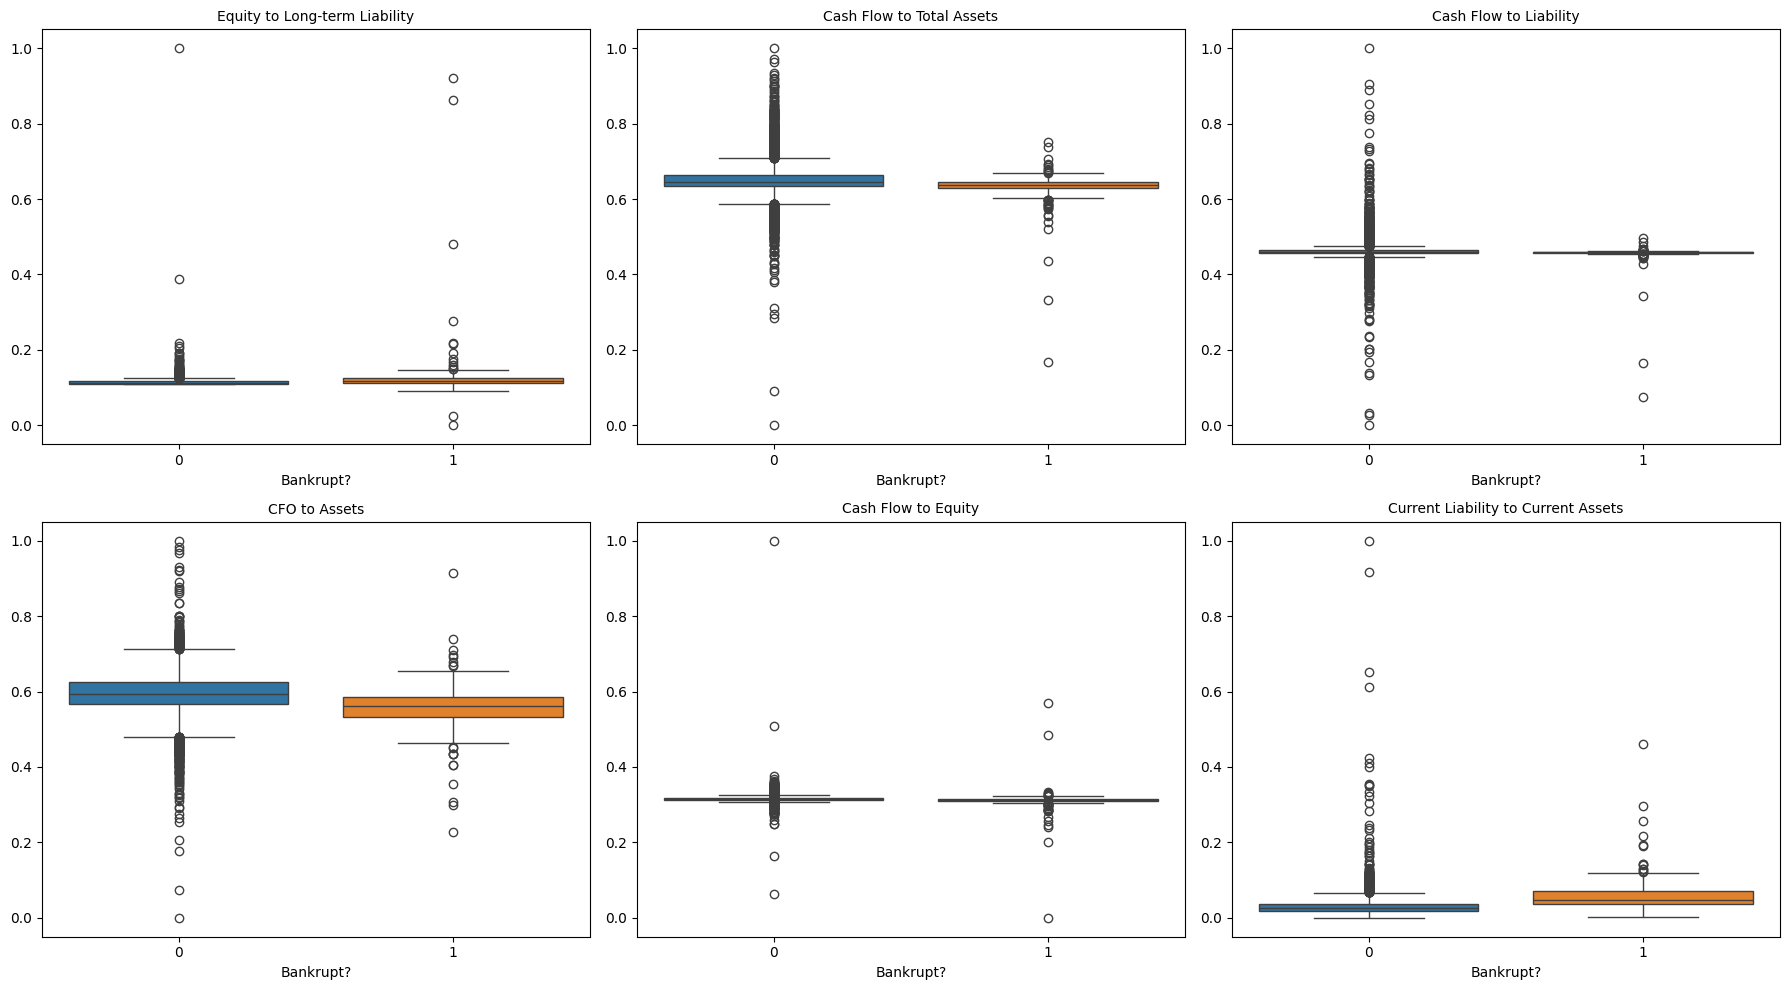

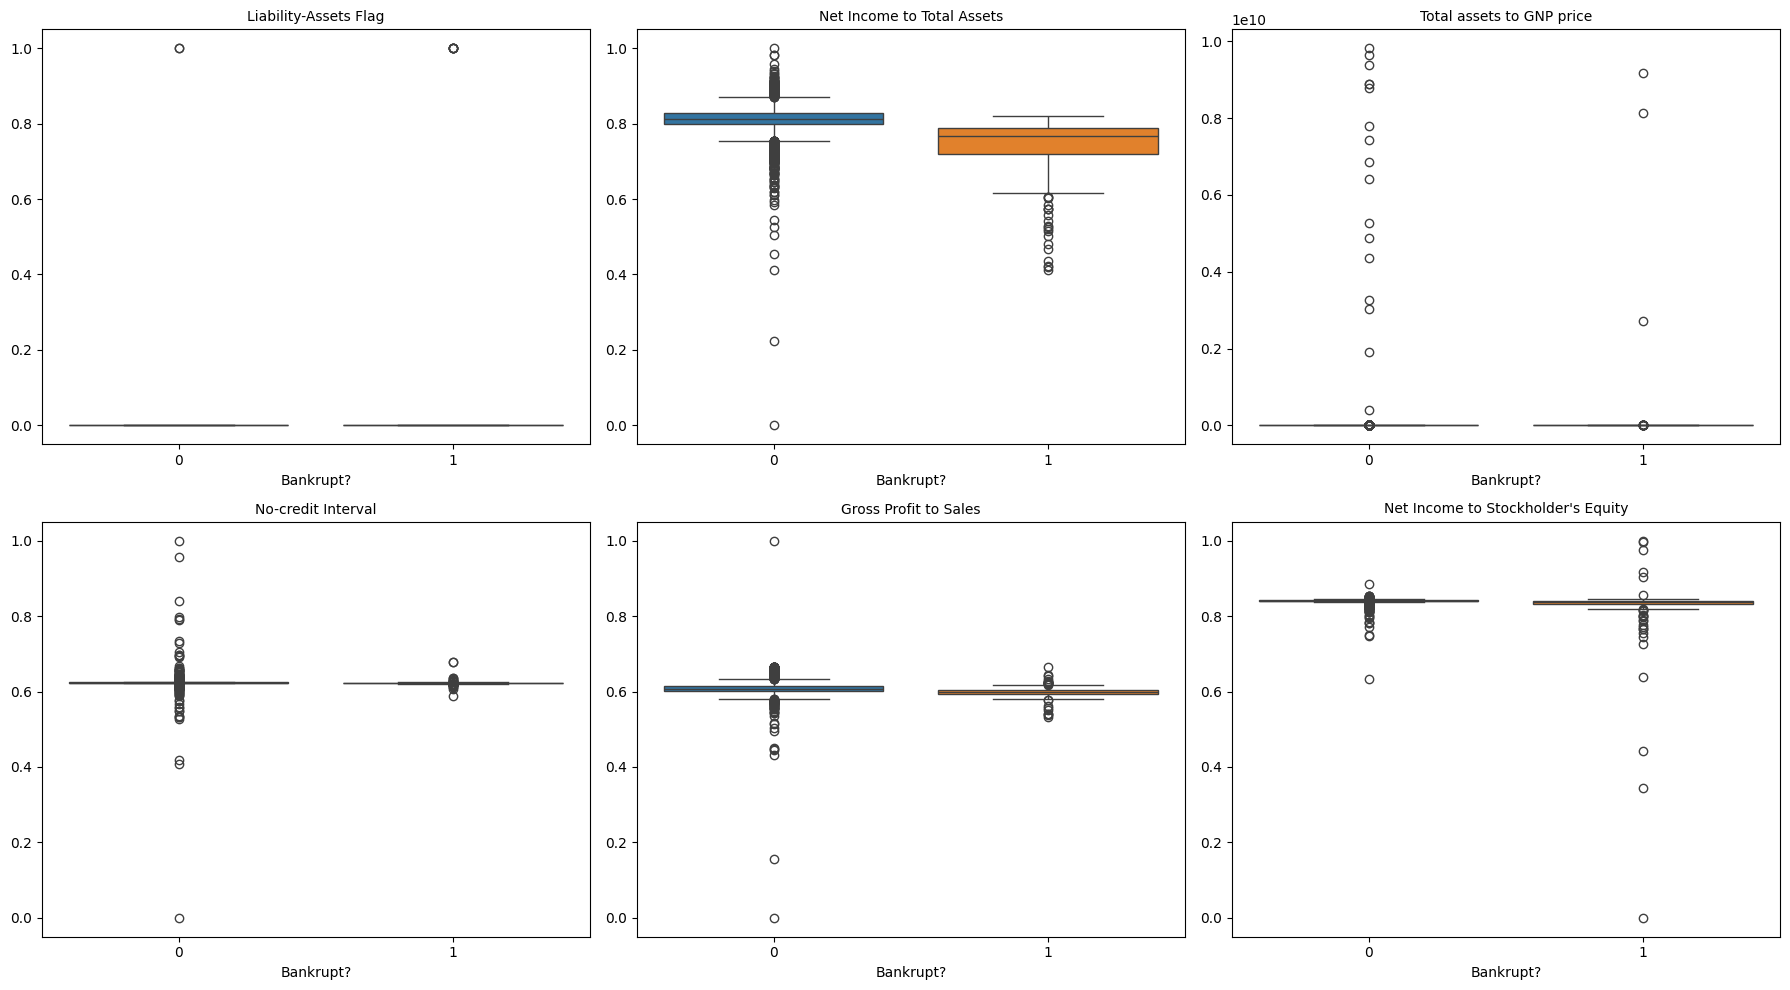

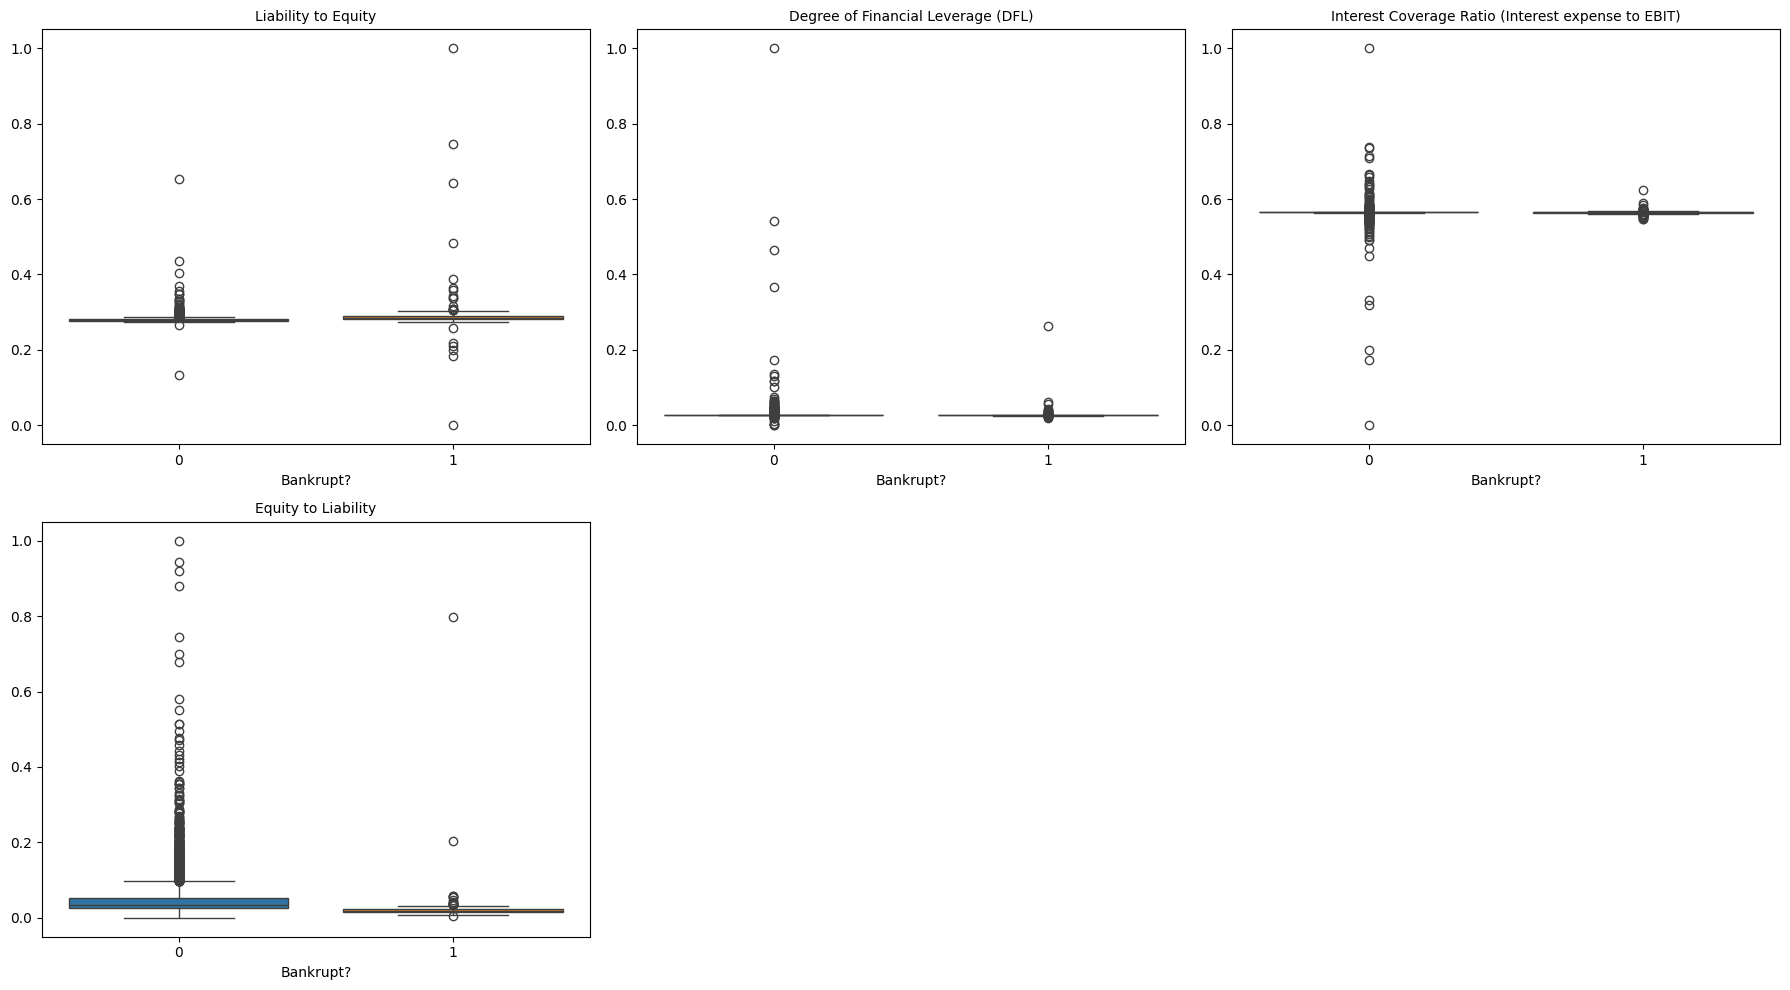

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil semua fitur kecuali target
features = [col for col in df.columns if col != 'Bankrupt?']

# Tampilkan 6 fitur per gambar
for i in range(0, len(features), 6):
    subset = features[i:i+6]

    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 10)
    )

    axes = axes.flatten()

    for j, col in enumerate(subset):
        sns.boxplot(
            data=df,
            x='Bankrupt?',
            y=col,
            hue='Bankrupt?',
            ax=axes[j],
            legend=False
        )

        axes[j].set_title(col, fontsize=10)
        axes[j].set_xlabel('Bankrupt?')
        axes[j].set_ylabel('')

    # Matikan subplot yang kosong
    for j in range(len(subset), 6):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


In [93]:
skewness = X.skew().sort_values(ascending=False)

# Buat tabel
skew_table = pd.DataFrame({
    'Skewness': skewness
})

# Klasifikasi distribusi
def classify_skew(value):
    if value > 0.5:
        return 'Right Skewed'
    elif value < -0.5:
        return 'Left Skewed'
    else:
        return 'Approximately Symmetric'

skew_table['Distribution'] = skew_table['Skewness'].apply(classify_skew)

skew_table

,Skewness,Distribution
Fixed Assets to Assets,82.577237,Right Skewed
Current Ratio,82.577237,Right Skewed
Total income/Total expense,82.332424,Right Skewed
Net Value Growth Rate,80.291844,Right Skewed
Contingent liabilities/Net worth,79.670620,Right Skewed
Realized Sales Gross Profit Growth Rate,77.925109,Right Skewed
Continuous Net Profit Growth Rate,67.097534,Right Skewed
Total Asset Return Growth Rate Ratio,62.499961,Right Skewed
Revenue per person,59.434480,Right Skewed
Quick Assets/Current Liability,47.947300,Right Skewed


In [94]:
import pandas as pd

X = df.drop(columns=['Bankrupt?'])

outlier_info = []

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()

    outlier_info.append({
        'Feature': col,
        'Skewness': X[col].skew(),
        'Outliers': outliers,
        'Outlier %': (outliers / len(X)) * 100
    })

outlier_df = pd.DataFrame(outlier_info)

outlier_df = outlier_df.sort_values(
    'Outlier %',
    ascending=False
)

display(outlier_df)

,Feature,Skewness,Outliers,Outlier %
91,Degree of Financial Leverage (DFL),45.724197,1503,22.041355
92,Interest Coverage Ratio (Interest expense to E...,-13.939528,1421,20.838833
48,Fixed Assets Turnover Frequency,2.349803,1418,20.794838
70,Current Asset Turnover Rate,2.115956,1399,20.516205
28,Total Asset Growth Rate,-0.918791,1381,20.252236
34,Interest Expense Ratio,-16.822554,1362,19.973603
80,Cash Flow to Liability,1.007963,1212,17.773867
87,No-credit Interval,-11.585565,1139,16.703329
8,Non-industry income and expenditure/revenue,39.641689,1094,16.043408
74,Cash Flow to Sales,-47.869112,1052,15.427482


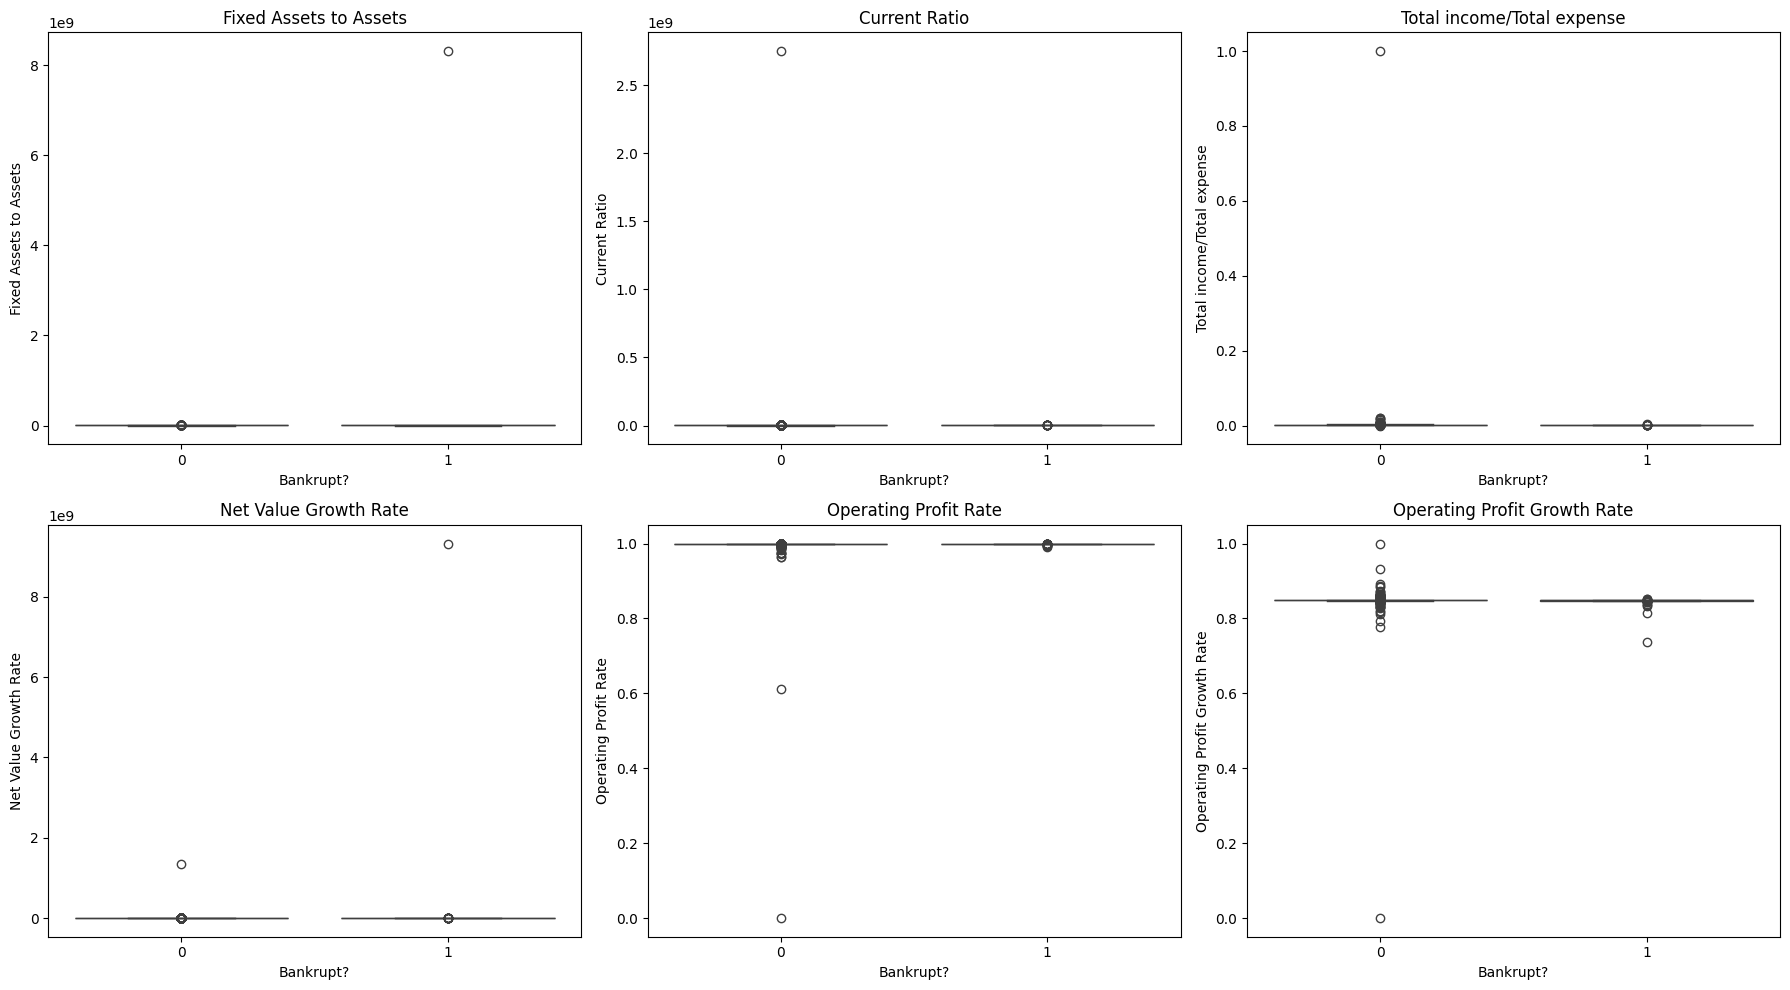

In [95]:
features_extreme = [
    'Fixed Assets to Assets',
    'Current Ratio',
    'Total income/Total expense',
    'Net Value Growth Rate',
    'Operating Profit Rate',
    'Operating Profit Growth Rate'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10)
)

for ax, col in zip(axes.flatten(), features_extreme):
    sns.boxplot(
        data=df,
        x='Bankrupt?',
        y=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel('Bankrupt?')

plt.tight_layout()
plt.show()

In [ ]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

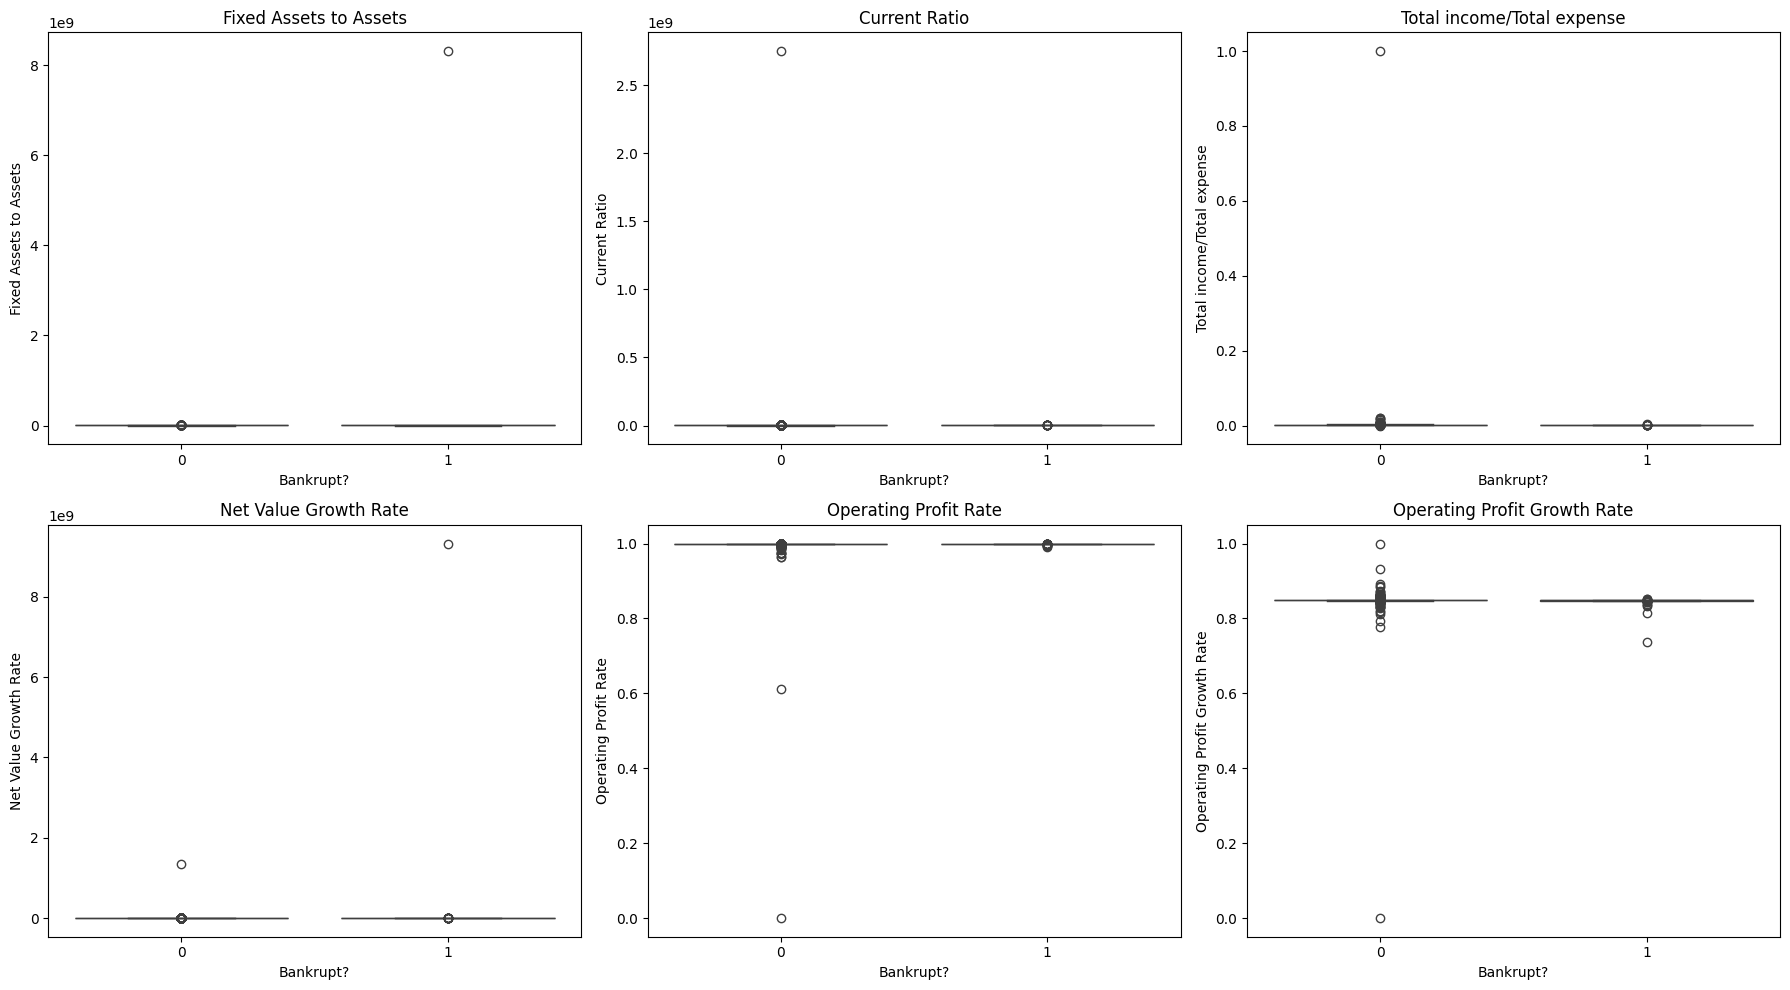

In [97]:
features = [
    'Fixed Assets to Assets',
    'Current Ratio',
    'Total income/Total expense',
    'Net Value Growth Rate',
    'Operating Profit Rate',
    'Operating Profit Growth Rate'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x='Bankrupt?',
        y=col,
        hue='Bankrupt?',
        legend=False,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()


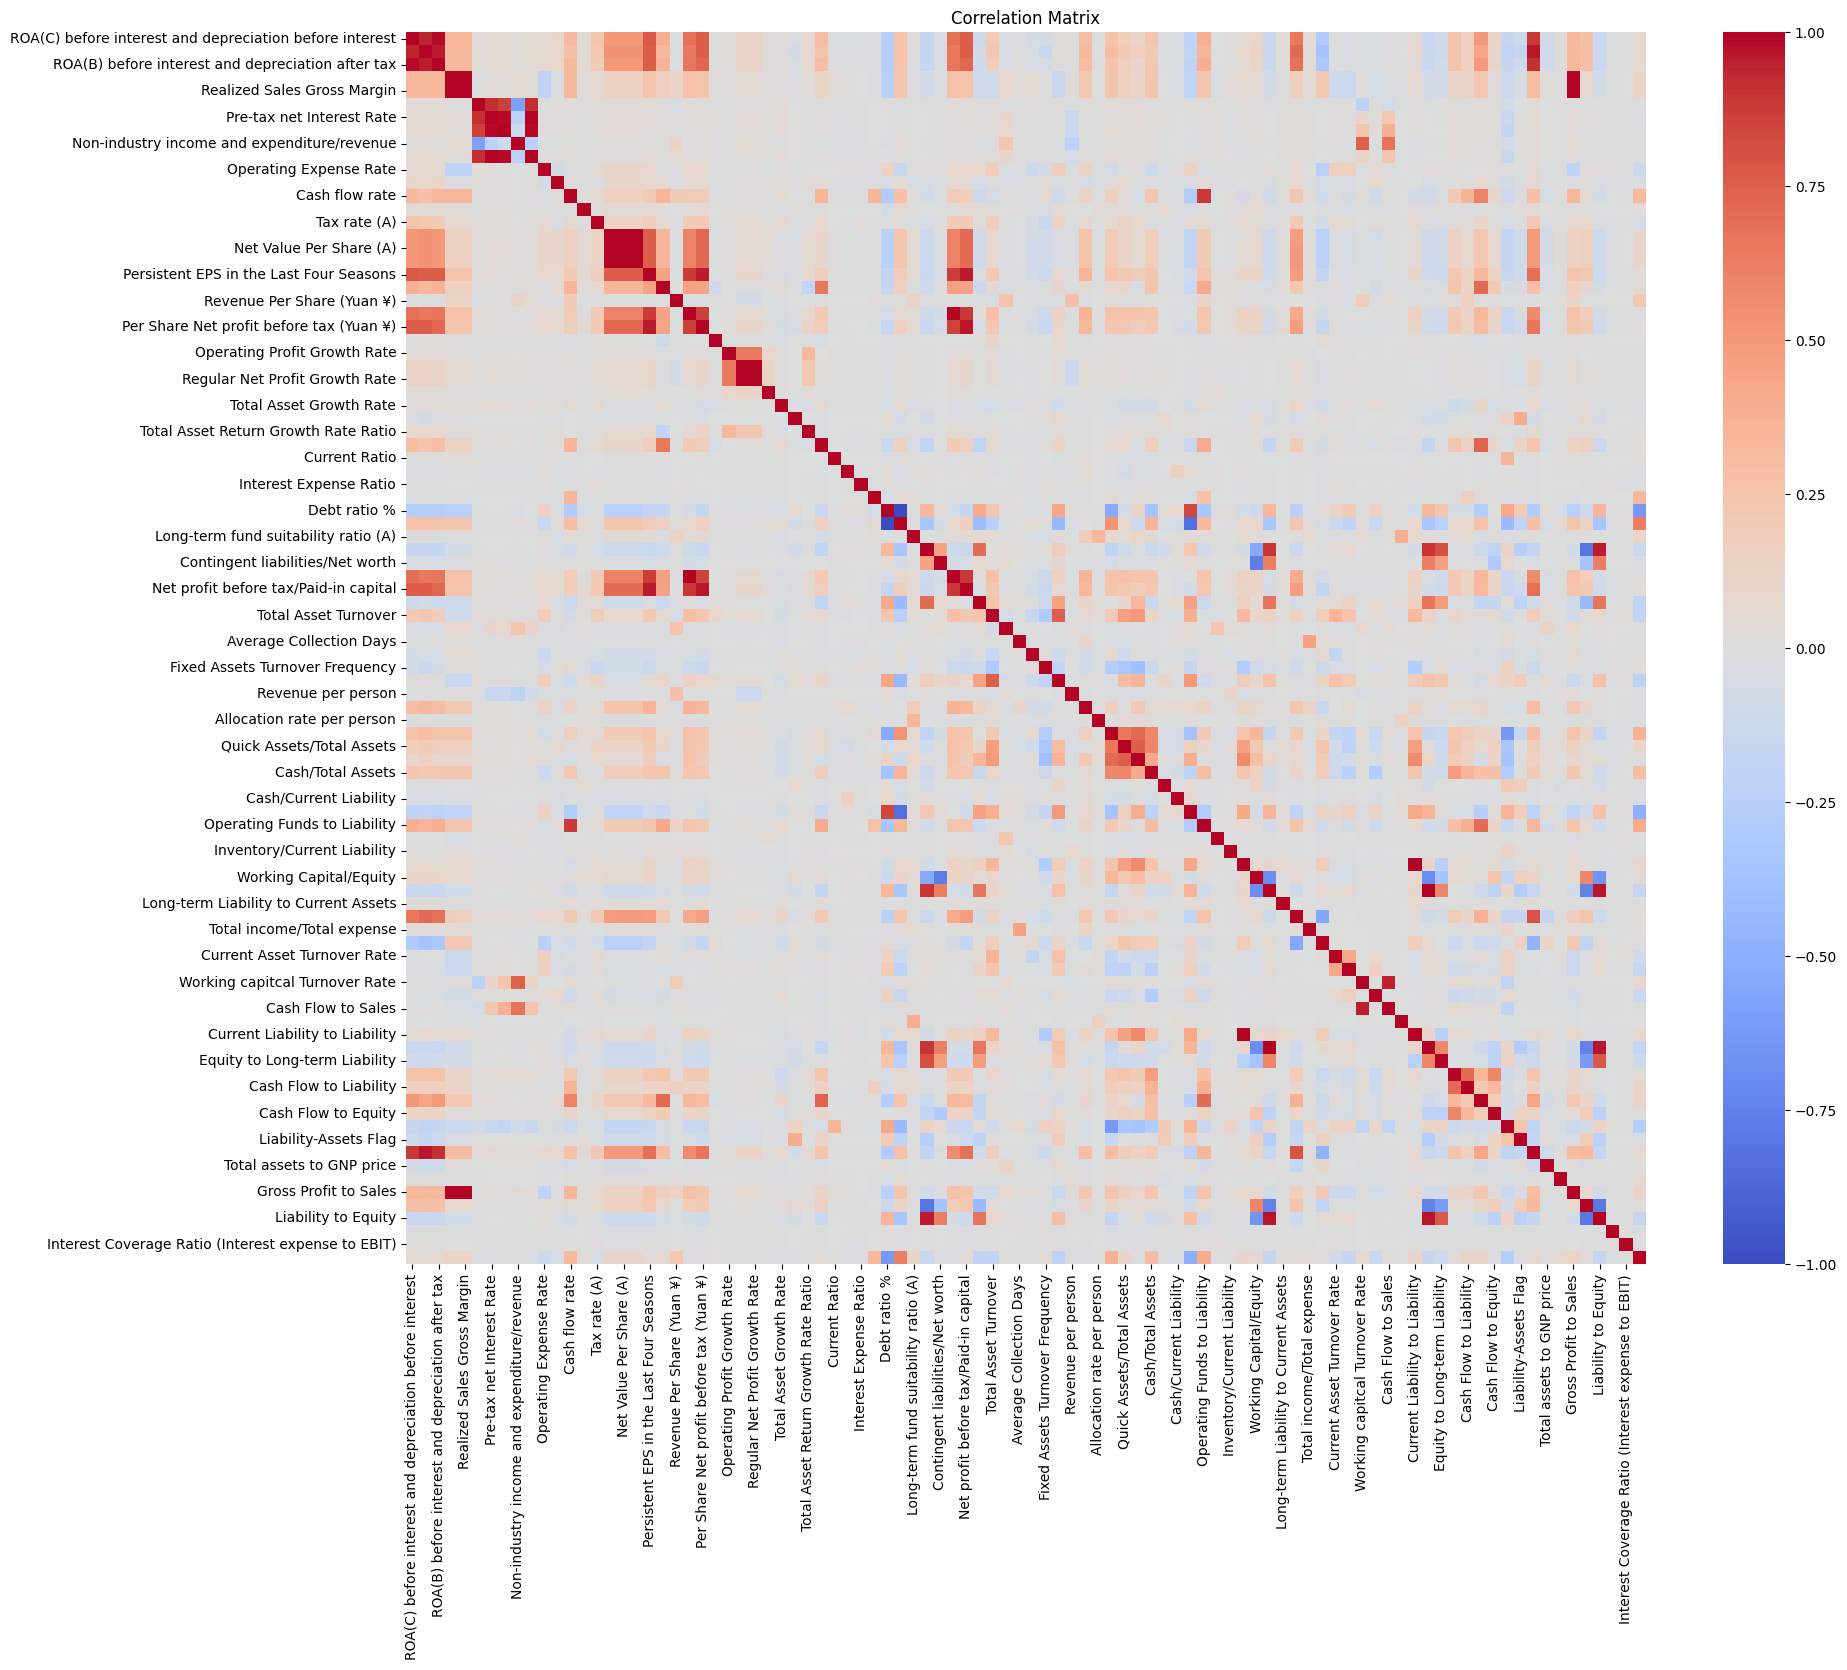

In [98]:
X = df.drop(columns=['Bankrupt?'])

corr = X.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

In [99]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = (
    upper
    .stack()
    .reset_index()
)

high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

high_corr = high_corr[
    high_corr['Correlation'] > 0.90
].sort_values(
    'Correlation',
    ascending=False
)

display(high_corr)


,Feature 1,Feature 2,Correlation
3918,Current Liabilities/Liability,Current Liability to Liability,1.000000
3976,Current Liabilities/Equity,Current Liability to Equity,1.000000
2718,Debt ratio %,Net worth/Assets,1.000000
360,Operating Gross Margin,Gross Profit to Sales,1.000000
1368,Net Value Per Share (A),Net Value Per Share (C),0.999837
276,Operating Gross Margin,Realized Sales Gross Margin,0.999518
449,Realized Sales Gross Margin,Gross Profit to Sales,0.999518
1290,Net Value Per Share (B),Net Value Per Share (A),0.999342
1291,Net Value Per Share (B),Net Value Per Share (C),0.999179
1762,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998696


# 2. Preprocessing

In [106]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [107]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

In [108]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=21
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5455, 94)
X_test : (1364, 94)
y_train: (5455,)
y_test : (1364,)


In [110]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = (
    upper
    .stack()
    .reset_index()
)

high_corr.columns = [
    'Feature 1',
    'Feature 2',
    'Correlation'
]

high_corr = high_corr[
    high_corr['Correlation'] >= 0.90
].sort_values(
    'Correlation',
    ascending=False
)

display(high_corr)


,Feature 1,Feature 2,Correlation
3976,Current Liabilities/Equity,Current Liability to Equity,1.000000
2718,Debt ratio %,Net worth/Assets,1.000000
3918,Current Liabilities/Liability,Current Liability to Liability,1.000000
360,Operating Gross Margin,Gross Profit to Sales,1.000000
1368,Net Value Per Share (A),Net Value Per Share (C),0.999787
276,Operating Gross Margin,Realized Sales Gross Margin,0.999487
449,Realized Sales Gross Margin,Gross Profit to Sales,0.999487
1290,Net Value Per Share (B),Net Value Per Share (A),0.999127
1291,Net Value Per Share (B),Net Value Per Share (C),0.998913
1762,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,0.998480


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

## **MODEL GINI**

In [111]:
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## **MODEL ENTROPY**

In [112]:
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [113]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
# Prediksi pada test set
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

# Tampilkan beberapa hasil prediksi
print("Prediksi Gini    :", y_pred_gini[:10])
print("Prediksi Entropy :", y_pred_entropy[:10])

Prediksi Gini    : [0 0 0 0 0 0 1 1 0 0]
Prediksi Entropy : [0 0 0 0 0 0 0 0 0 0]


In [114]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

In [115]:
print("=== Decision Tree - Gini ===")
evaluate_model(dt_gini, X_test, y_test)

print("\n=== Decision Tree - Entropy ===")
evaluate_model(dt_entropy, X_test, y_test)

=== Decision Tree - Gini ===
Accuracy : 0.9479472140762464
Precision: 0.24528301886792453
Recall   : 0.29545454545454547
F1 Score : 0.26804123711340205

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1320
           1       0.25      0.30      0.27        44

    accuracy                           0.95      1364
   macro avg       0.61      0.63      0.62      1364
weighted avg       0.95      0.95      0.95      1364


=== Decision Tree - Entropy ===
Accuracy : 0.9574780058651027
Precision: 0.34782608695652173
Recall   : 0.36363636363636365
F1 Score : 0.35555555555555557

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.35      0.36      0.36        44

    accuracy                           0.96      1364
   macro avg       0.66      0.67      0.67      1364
weighted avg       0.96      0.96      0.96  

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [ ]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

In [ ]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

In [ ]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

In [ ]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

In [ ]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

In [ ]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.